In [42]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import warnings
import cellrank
import gseapy
import IPython

In [2]:
# Read input file

working_directory = "RNA Sequencing Data/"

# Use adata from velocity analysis
adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'manual_root', 'manual_end', 'sde_velocity_pseudotime'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'log1p', 'neighbors', 'pca', 'sample_colors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_pca', 'X_umap', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'pred_s', 'pred_u', 'sde_velocity', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'


In [3]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

In [4]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="sde_velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

  0%|          | 0/12791 [00:00<?, ?cell/s]

VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344]

In [5]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [6]:
# Kernel based on gene expression similarity

# Neigborhood calculation is based on 30 pcs, 30 neighbors
print(adata.uns["neighbors"])

connectivity_kernel = cellrank.kernels.ConnectivityKernel(adata)
connectivity_kernel.compute_transition_matrix()

{'connectivities_key': 'connectivities', 'distances_key': 'distances', 'params': {'method': 'umap', 'metric': 'euclidean', 'n_neighbors': 30, 'n_pcs': 30, 'random_state': 0}}


ConnectivityKernel[n=12791, dnorm=True, key='connectivities']

In [7]:
# Combine all three kernels

combined_kernel = 0.4*velocity_kernel + 0.4*latent_time_kernel + 0.2*connectivity_kernel
combined_kernel.compute_transition_matrix()

(0.4 * VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344] + 0.4 * PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.2 * ConnectivityKernel[n=12791, dnorm=True, key='connectivities'])

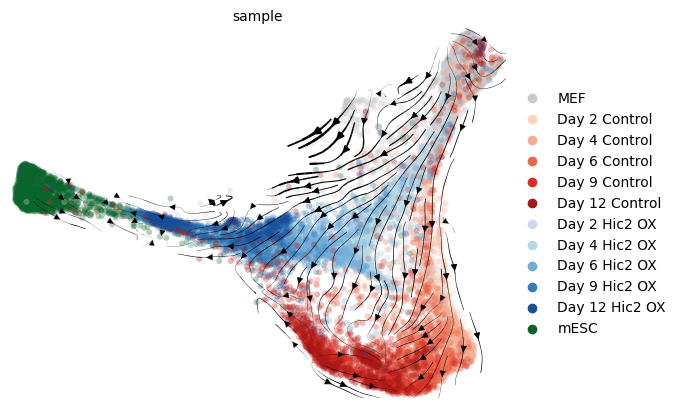

In [8]:
# Plot kernel vector field

combined_kernel.plot_projection(basis="fdl", color="sample", legend_loc="right margin")

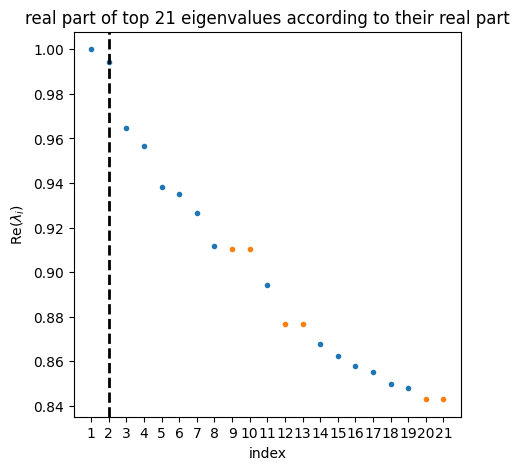

In [9]:
estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

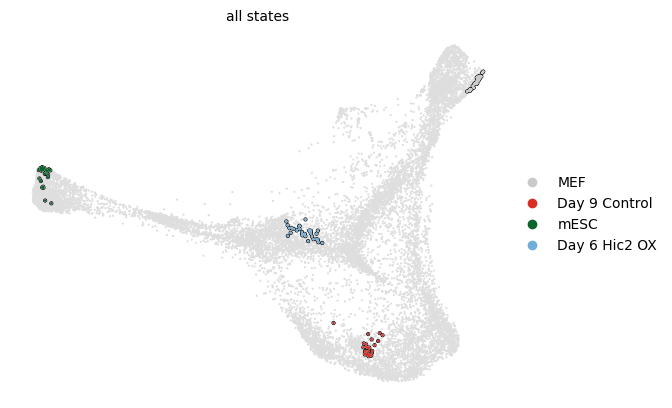

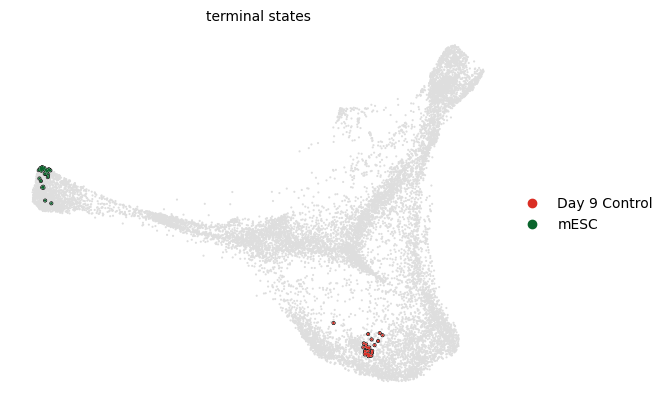

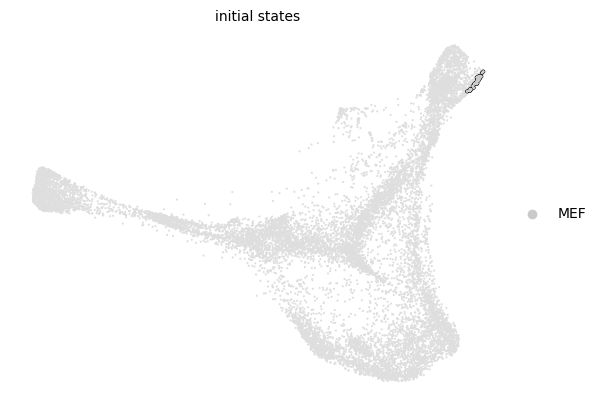

In [10]:
estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_macrostates(n_states=4, cluster_key="sample")

estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states

estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states

estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)
initial_states = estimator.initial_states_memberships.names

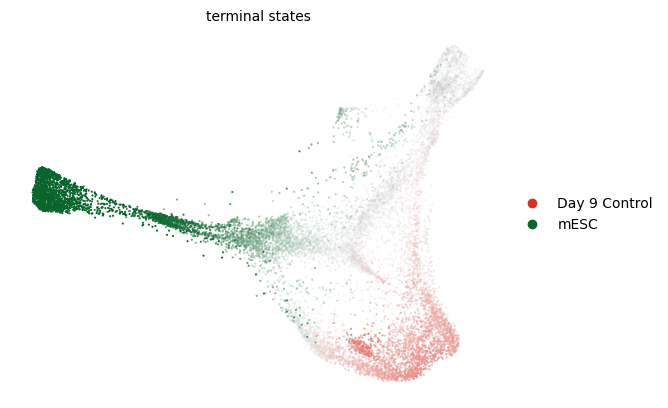

In [11]:
# Plot probability of cells belonging to the terminal states

estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=False, basis="fdl")

In [12]:
# Plot stability values. These are used to find terminal states with method="stability" and show that Day 4 control and Day 9 Hic2 OX are metastable

stability_values = estimator.coarse_T.values.diagonal()

stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)

print(stability_df)

      Macrostate  Stability
2           mESC   0.999304
1  Day 9 Control   0.984447
3  Day 6 Hic2 OX   0.967967
0            MEF   0.963973


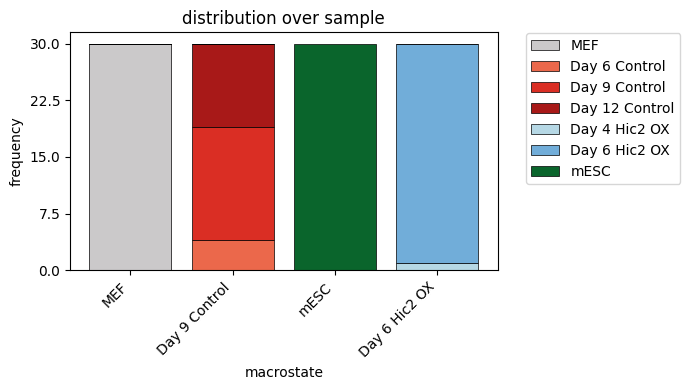

In [13]:
estimator.plot_macrostate_composition(key="sample", figsize=(7, 4))

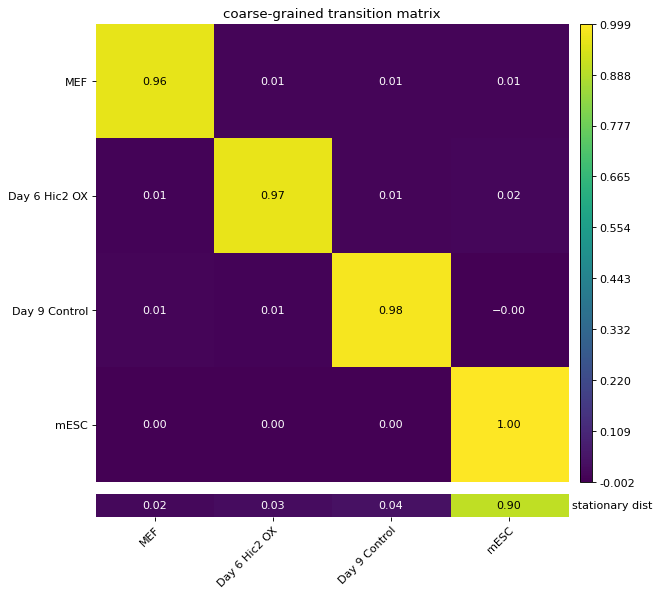

In [14]:
estimator.plot_coarse_T()

  0%|          | 0/2 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


  0%|          | 0/2 [00:00<?, ?/s]

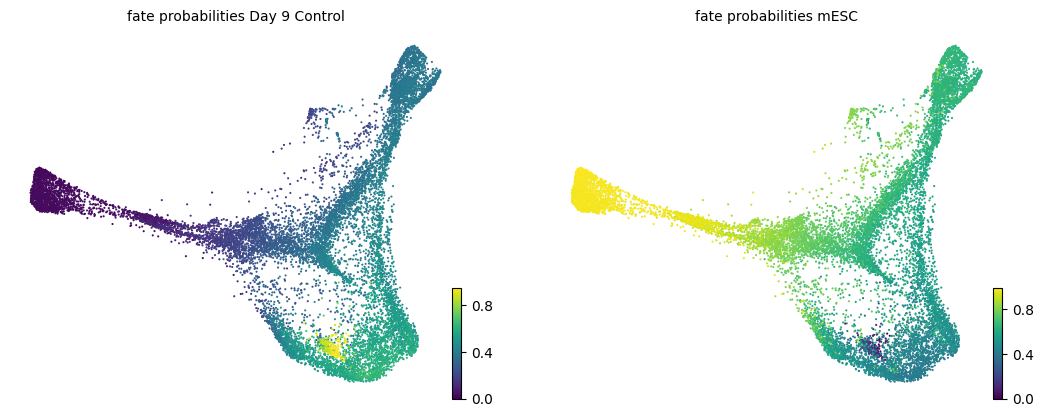

In [15]:
# Estimate fate probabilities

estimator.compute_fate_probabilities()

# Add fate probabilities to adata
for terminal_state in terminal_states:
    adata.obs[f"fate_probabilities_{terminal_state}"] = estimator.fate_probabilities[terminal_state].X.flatten()
estimator.compute_fate_probabilities()
estimator.plot_fate_probabilities(same_plot=False, basis="fdl")

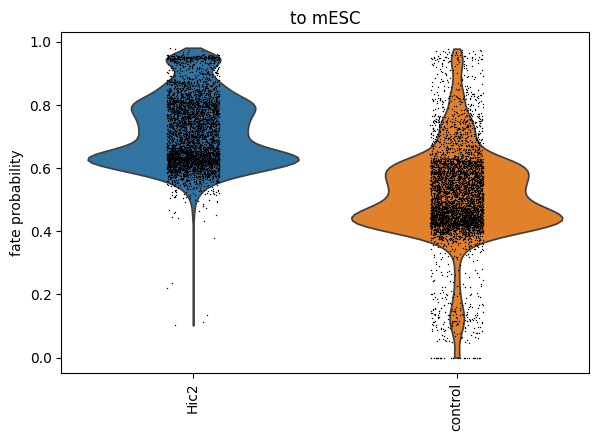

In [17]:
# Aggregate fate probabilities

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

In [18]:
# Find driver genes for all terminal states

reprogramming_groups = ["Hic2", "control"]

driver_df = estimator.compute_lineage_drivers(
    cluster_key="group", clusters=reprogramming_groups
)
corr_columns = [state+"_corr" for state in terminal_states]

In [19]:
# Drivers for mESCs
driver_df.sort_values("mESC_corr", ascending=False).head(20)[corr_columns]

,Day 9 Control_corr,mESC_corr
gene_names,,
Rbpms2,-0.602148,0.602149
Mdk,-0.589390,0.589385
Fbxo15,-0.588147,0.588148
Folr1,-0.579189,0.579189
Utf1,-0.576936,0.576937
Apoc1,-0.566848,0.566848
Dnmt3l,-0.561073,0.561075
Gdf3,-0.559180,0.559180
Klhl13,-0.558672,0.558676


In [21]:
# Drivers for Day 12 control
driver_df.sort_values("Day 9 Control_corr", ascending=False).head(20)[corr_columns]

,Day 9 Control_corr,mESC_corr
gene_names,,
Cd24a,0.666189,-0.666206
Lmo1,0.592017,-0.592016
Crip2,0.579862,-0.579871
Ctsz,0.575449,-0.575480
Lgals7,0.573030,-0.573027
Rtn4r,0.571579,-0.571579
Tmem238,0.536695,-0.536699
Pcolce2,0.526165,-0.526163
S100a16,0.524595,-0.524600


In [22]:
# How specific genes correlate with terminal states
genes_of_interest = ["Krtdap", "Krt8", "Krt14", "Nanog", "Tet1", "Cdh1", "Ovol1", "Atf3"]
terminal_states = list(adata.obs["term_states_fwd"].dropna().unique())
corr_columns = [state+"_corr" for state in terminal_states]
driver_df.loc[genes_of_interest]

,Day 9 Control_corr,Day 9 Control_pval,Day 9 Control_qval,Day 9 Control_ci_low,Day 9 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Krtdap,0.109065,9.841132e-27,2.205695e-26,0.089211,0.128833,-0.109060,9.901809e-27,2.219294e-26,-0.128827,-0.089205
Krt8,0.440374,0.000000e+00,0.000000e+00,0.424068,0.456393,-0.440369,0.000000e+00,0.000000e+00,-0.456388,-0.424063
Krt14,0.343405,3.492931e-268,3.274828e-267,0.325598,0.360969,-0.343401,3.543975e-268,3.322685e-267,-0.360965,-0.325594
Nanog,-0.309771,3.775783e-215,2.888980e-214,-0.327784,-0.291532,0.309769,3.801337e-215,2.908533e-214,0.291530,0.327782
Tet1,-0.484743,0.000000e+00,0.000000e+00,-0.499934,-0.469255,0.484746,0.000000e+00,0.000000e+00,0.469257,0.499936
Cdh1,0.308565,2.222554e-213,1.668586e-212,0.290312,0.326594,-0.308565,2.223364e-213,1.669195e-212,-0.326593,-0.290311
Ovol1,0.443967,0.000000e+00,0.000000e+00,0.427725,0.459922,-0.443968,0.000000e+00,0.000000e+00,-0.459923,-0.427726
Atf3,0.339447,1.447587e-261,1.332180e-260,0.321587,0.357066,-0.339449,1.439469e-261,1.324709e-260,-0.357068,-0.321588


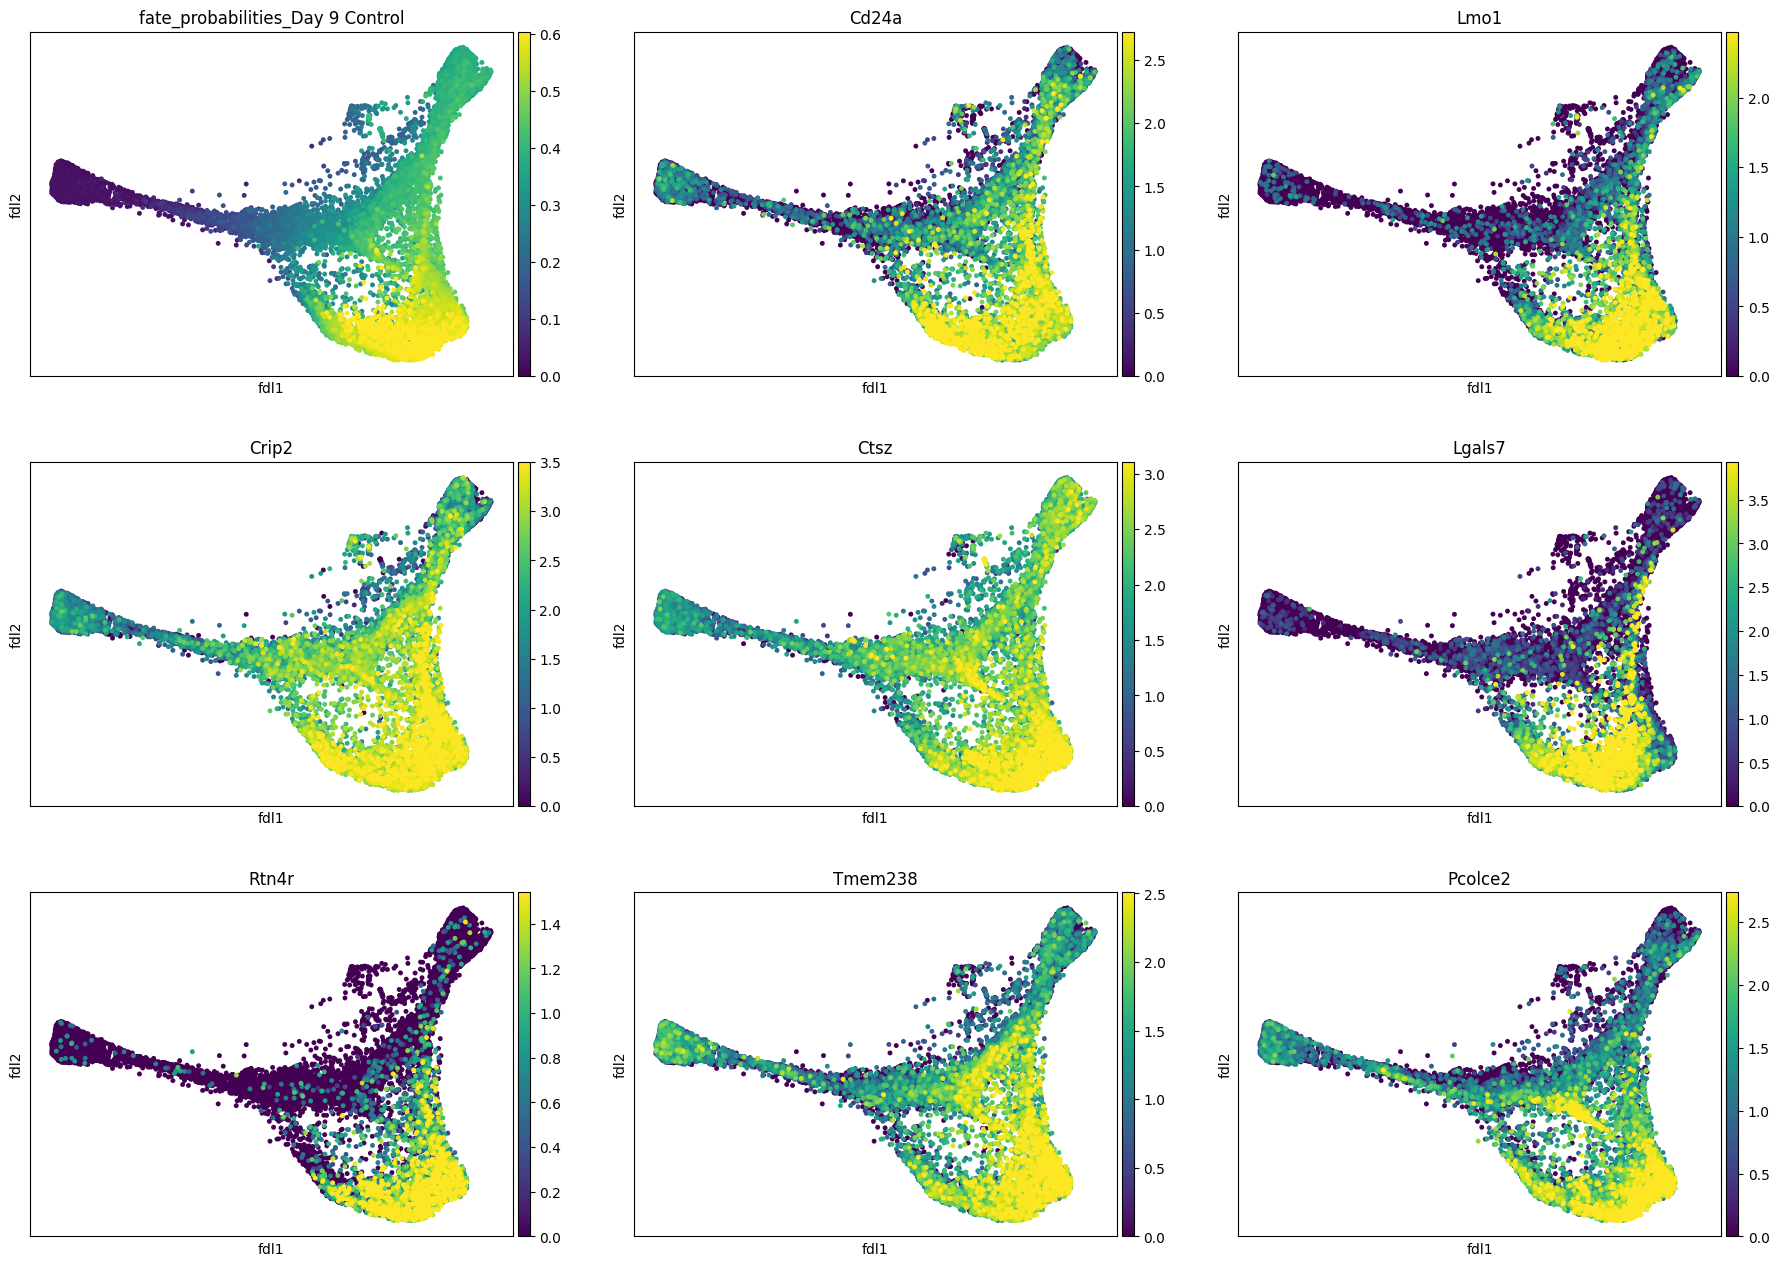

In [26]:
# Visualize driver genes for day 12 control

terminal_state = "Day 9 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

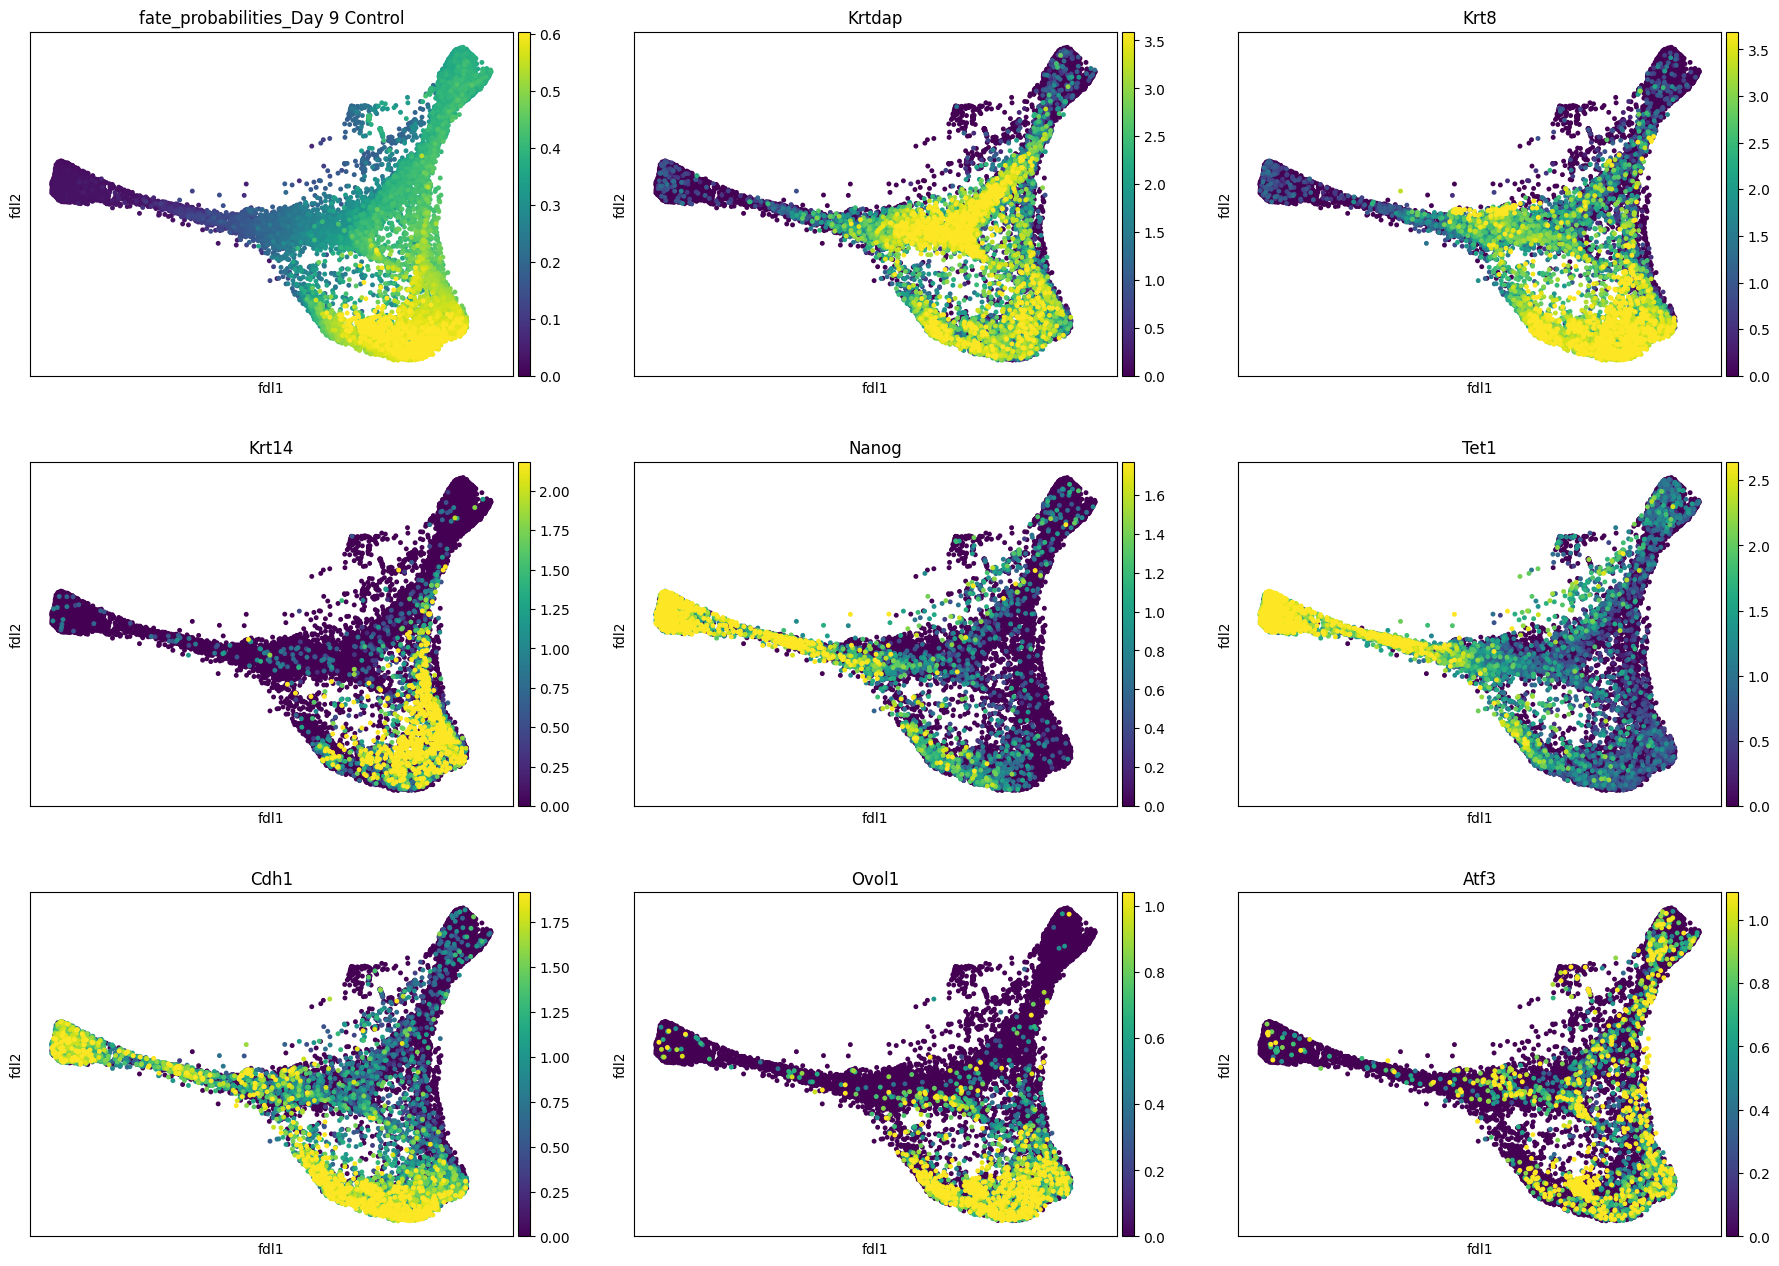

In [25]:
# Visualize genes of interest

terminal_state = "Day 9 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + genes_of_interest,
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

In [27]:
# Gene expression over time

# Create model
model = cellrank.models.GAMR(adata, n_knots=6, smoothing_penalty=10.0) # GAMR can be used instead to have the R model

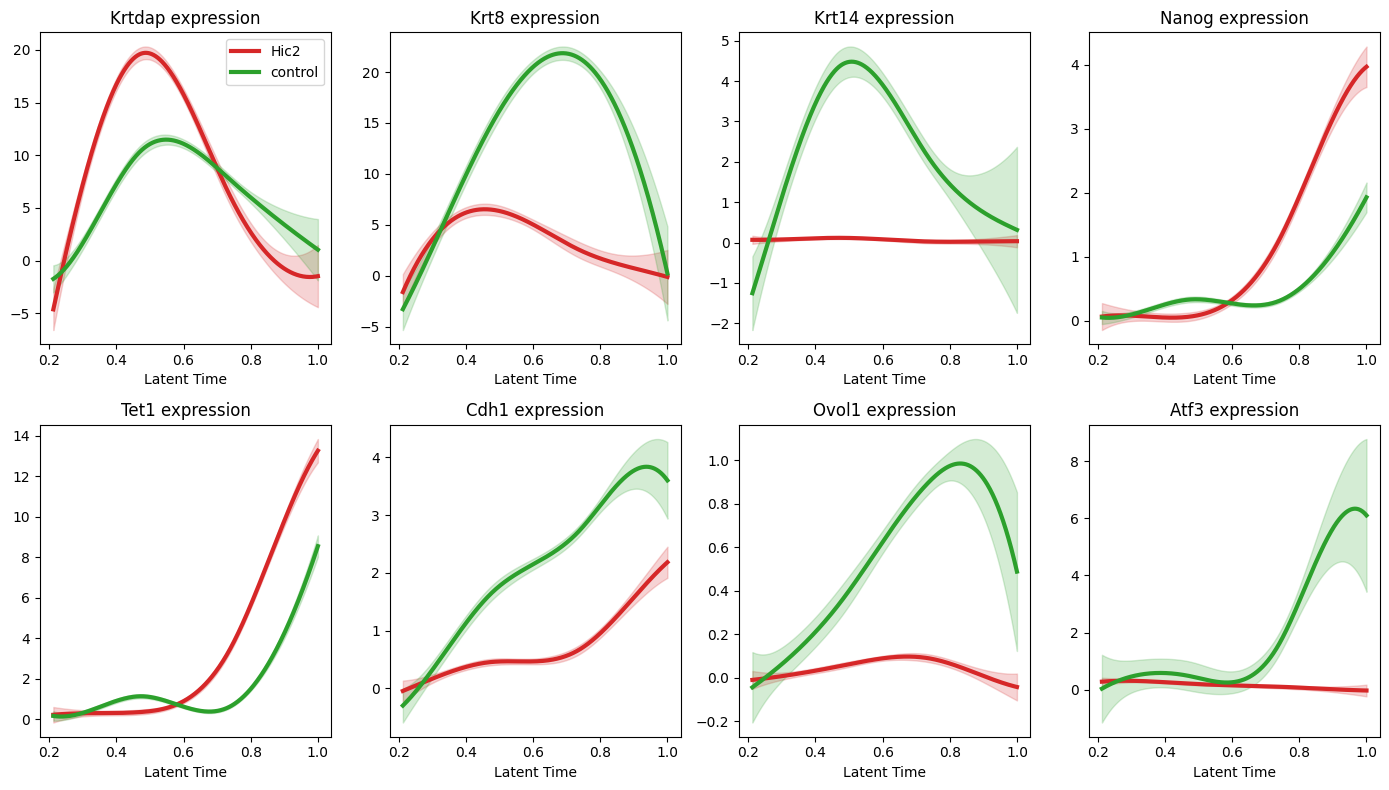

In [28]:
# Trends independent of trajectory

import pygam

def plot_grouped_gene_trend(adata, genes, group_key="group", time_key="latent_time", layer="Ms", groups=None, columns=4, figure_width=14, plot_height=4):
    """
    Plots smoothed gene expression using Generalized Additive Models (GAMs).
    This provides true smooth local regression with confidence intervals.
    """

    number_of_genes = len(genes)
    number_of_columns = min(columns, number_of_genes)
    
    # Calculate rows
    rows = (number_of_genes + number_of_columns - 1) // number_of_columns
    
    figure, axes = pyplot.subplots(rows, number_of_columns)
    figure.set_figwidth(figure_width)
    figure.set_figheight(plot_height * rows)

    # Handle single gene case (axes is not an array) and 1D array case
    if number_of_genes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    # Define colors for groups
    unique_groups = adata.obs[group_key].unique()
    palette = seaborn.color_palette("tab10", n_colors=len(unique_groups))
    color_map = dict(zip(unique_groups, palette))

    for gene_index, gene in enumerate(genes):
        axis = axes_flat[gene_index]
        
        # Fetch expression data
        expr_data = adata[:, gene].layers[layer]
        if hasattr(expr_data, "toarray"):
            expr_data = expr_data.toarray()
        expr_data = expr_data.flatten()
        
        # Create DataFrame
        df = pandas.DataFrame({
            "Latent Time": adata.obs[time_key],
            "Expression": expr_data,
            "Group": adata.obs[group_key]
        })
        
        # Determine which groups to plot
        if groups is None:
            # If no specific list, plot all groups found in the data
            plot_groups = df["Group"].unique()
        else:
            plot_groups = groups

        # Loop through each group and fit a GAM
        for group in plot_groups:
            group_data = df[df["Group"] == group]
            
            # Skip empty groups
            if len(group_data) < 10:
                continue

            # Prepare X and y for pygam (X must be 2D array)
            X = group_data["Latent Time"].values.reshape(-1, 1)
            y = group_data["Expression"].values
            
            # Fit LinearGAM using a Spline term s(0)
            # n_splines=20 gives good flexibility (smoothness)
            gam = pygam.LinearGAM(pygam.s(0, n_splines=6)).fit(X, y)
            
            # Generate a smooth grid for plotting lines
            X_grid = numpy.linspace(X.min(), X.max(), 500)
            
            # Predict values and confidence intervals
            y_pred = gam.predict(X_grid)
            confidence_intervals = gam.confidence_intervals(X_grid, width=0.95)
            
            # Plot Line
            color = color_map[group]
            axis.plot(X_grid, y_pred, label=group, color=color, linewidth=3)
            
            # Plot Confidence Interval (Fill)
            axis.fill_between(
                X_grid, 
                confidence_intervals[:, 0], 
                confidence_intervals[:, 1], 
                color=color, 
                alpha=0.2 # Transparency of CI
            )

        axis.set_title(f"{gene} expression")
        axis.set_xlabel("Latent Time")
        
        # Add legend only to the first plot to avoid clutter
        if gene_index == 0:
            axis.legend()

    # Clean up empty subplots
    for i in range(number_of_genes, len(axes_flat)):
        axes_flat[i].axis('off')

    pyplot.tight_layout()
    pyplot.show()

# Example usage
plot_grouped_gene_trend(
    adata, 
    genes_of_interest, 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

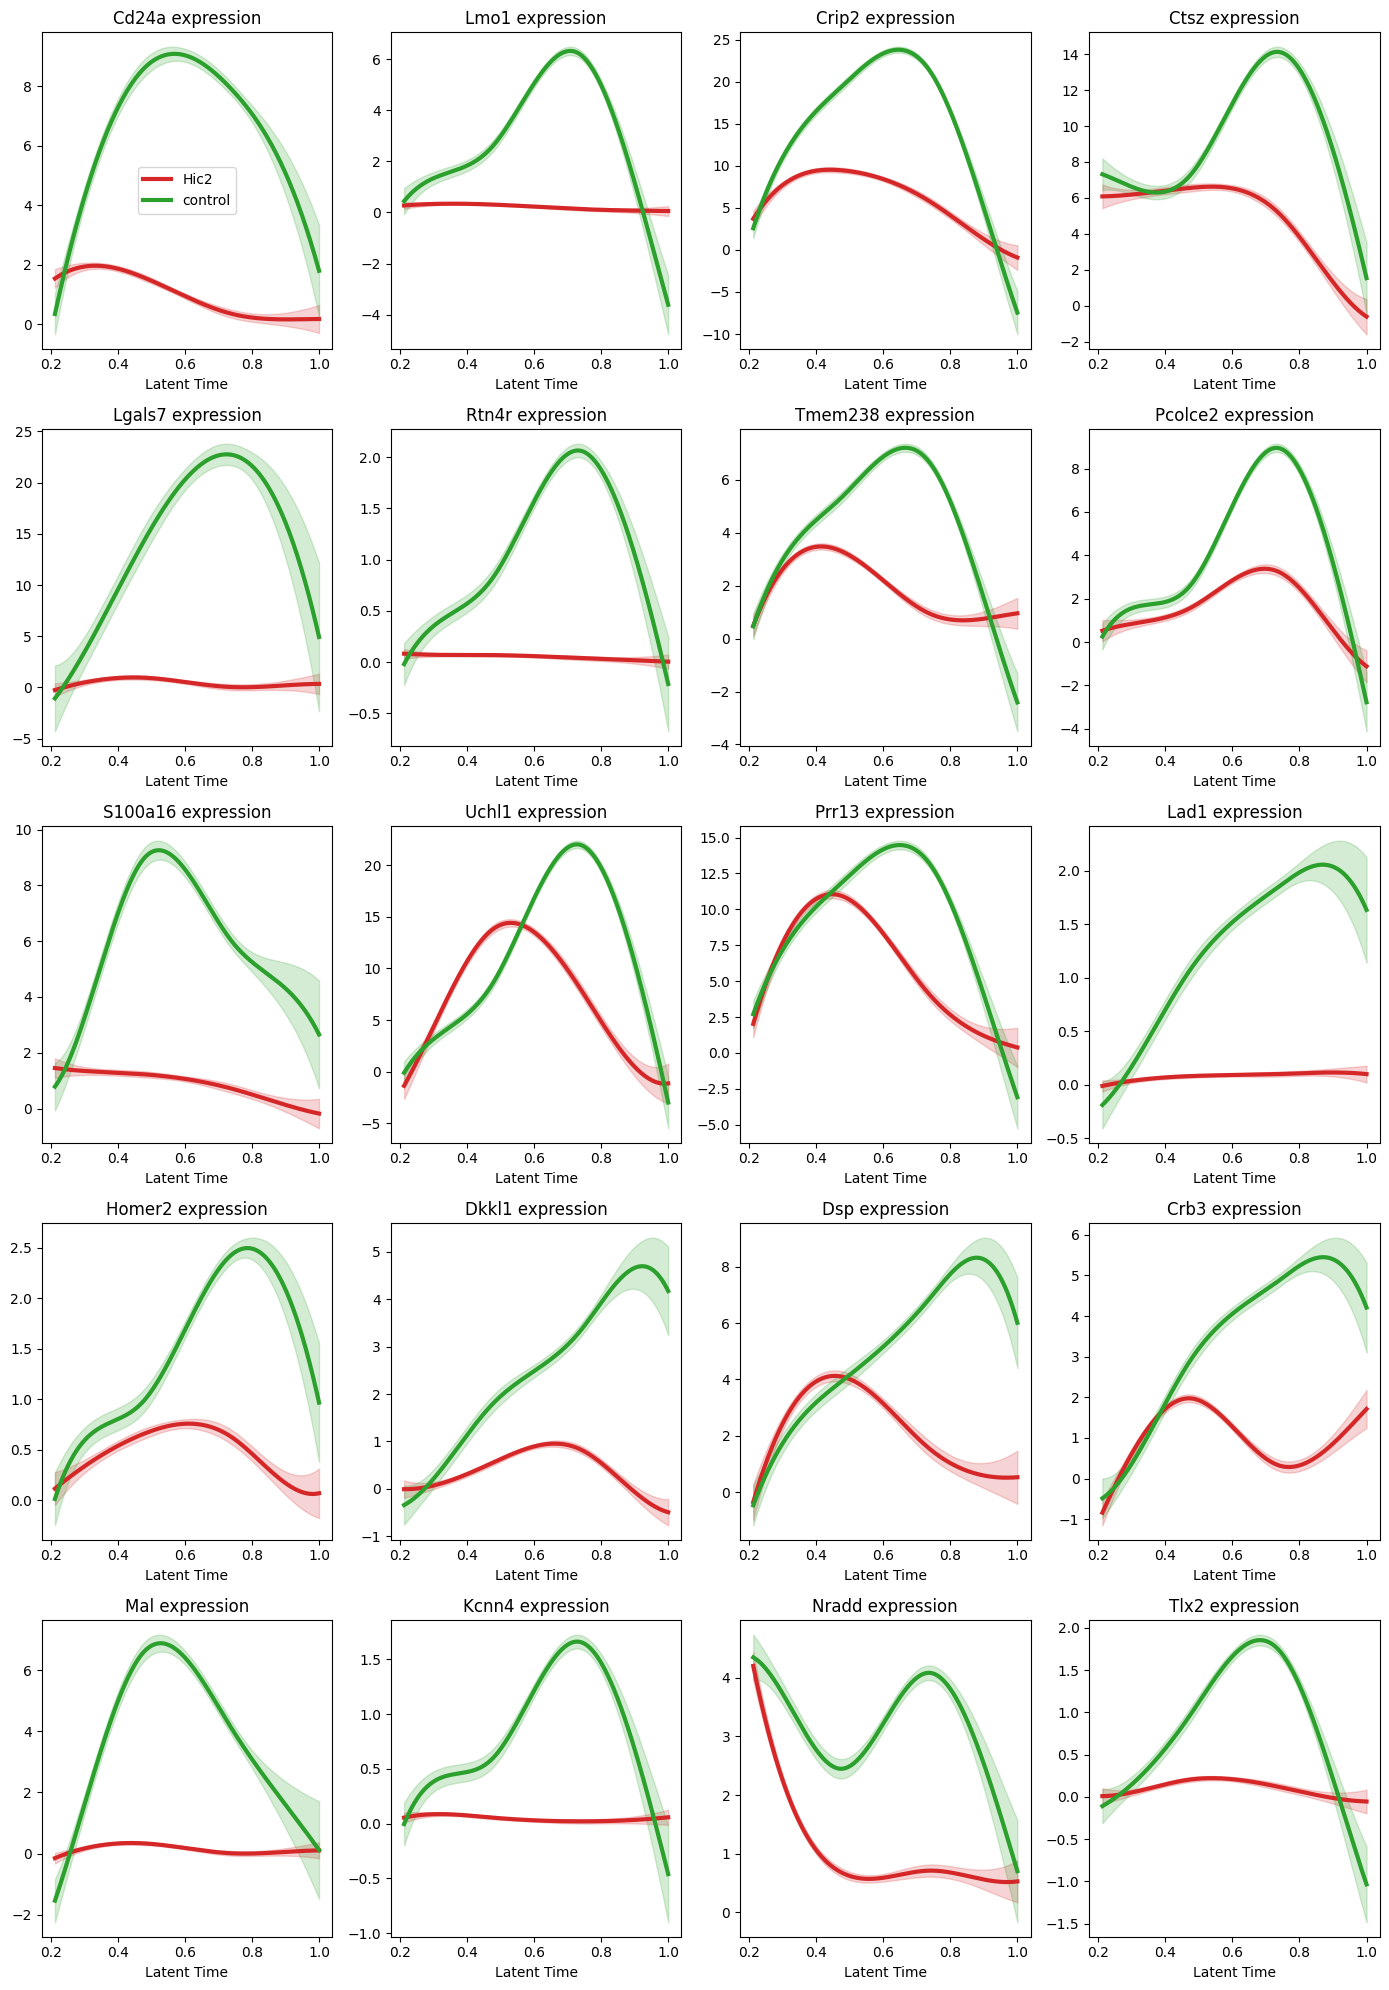

In [30]:
# Expression of drivers
control_driver_genes = driver_df.sort_values(f"Day 9 Control_corr", ascending=False).head(20).index

plot_grouped_gene_trend(
    adata, 
    control_driver_genes, 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

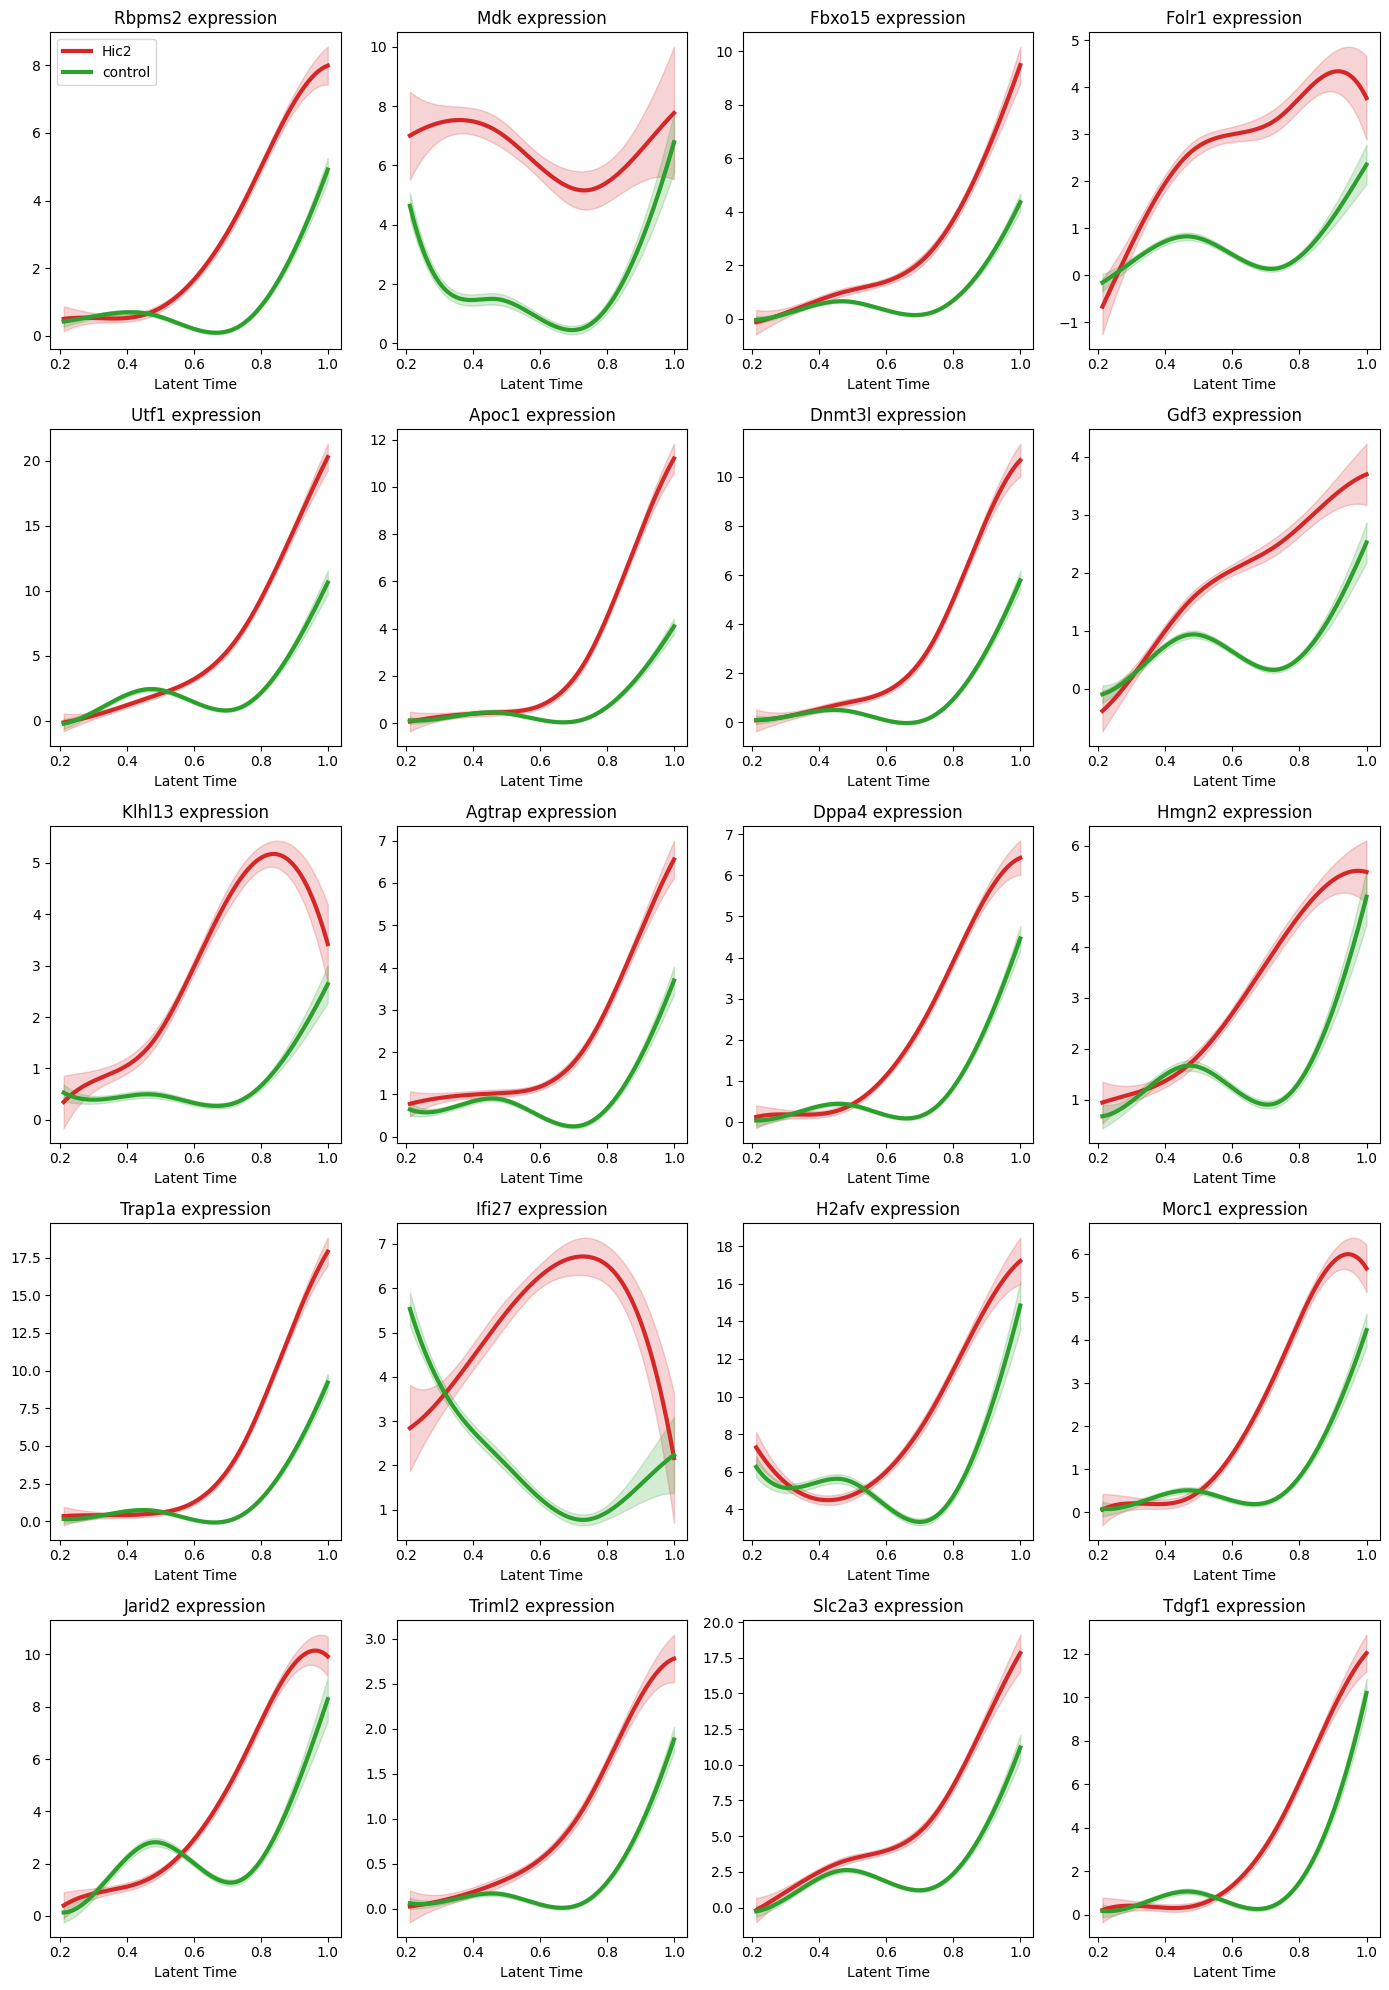

In [32]:
# Expression of reprogramming drivers
mesc_driver_genes = driver_df.sort_values(f"Day 9 Control_corr", ascending=True).head(20).index

plot_grouped_gene_trend(
    adata, 
    mesc_driver_genes, 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

  0%|          | 0/10 [00:00<?, ?gene/s]

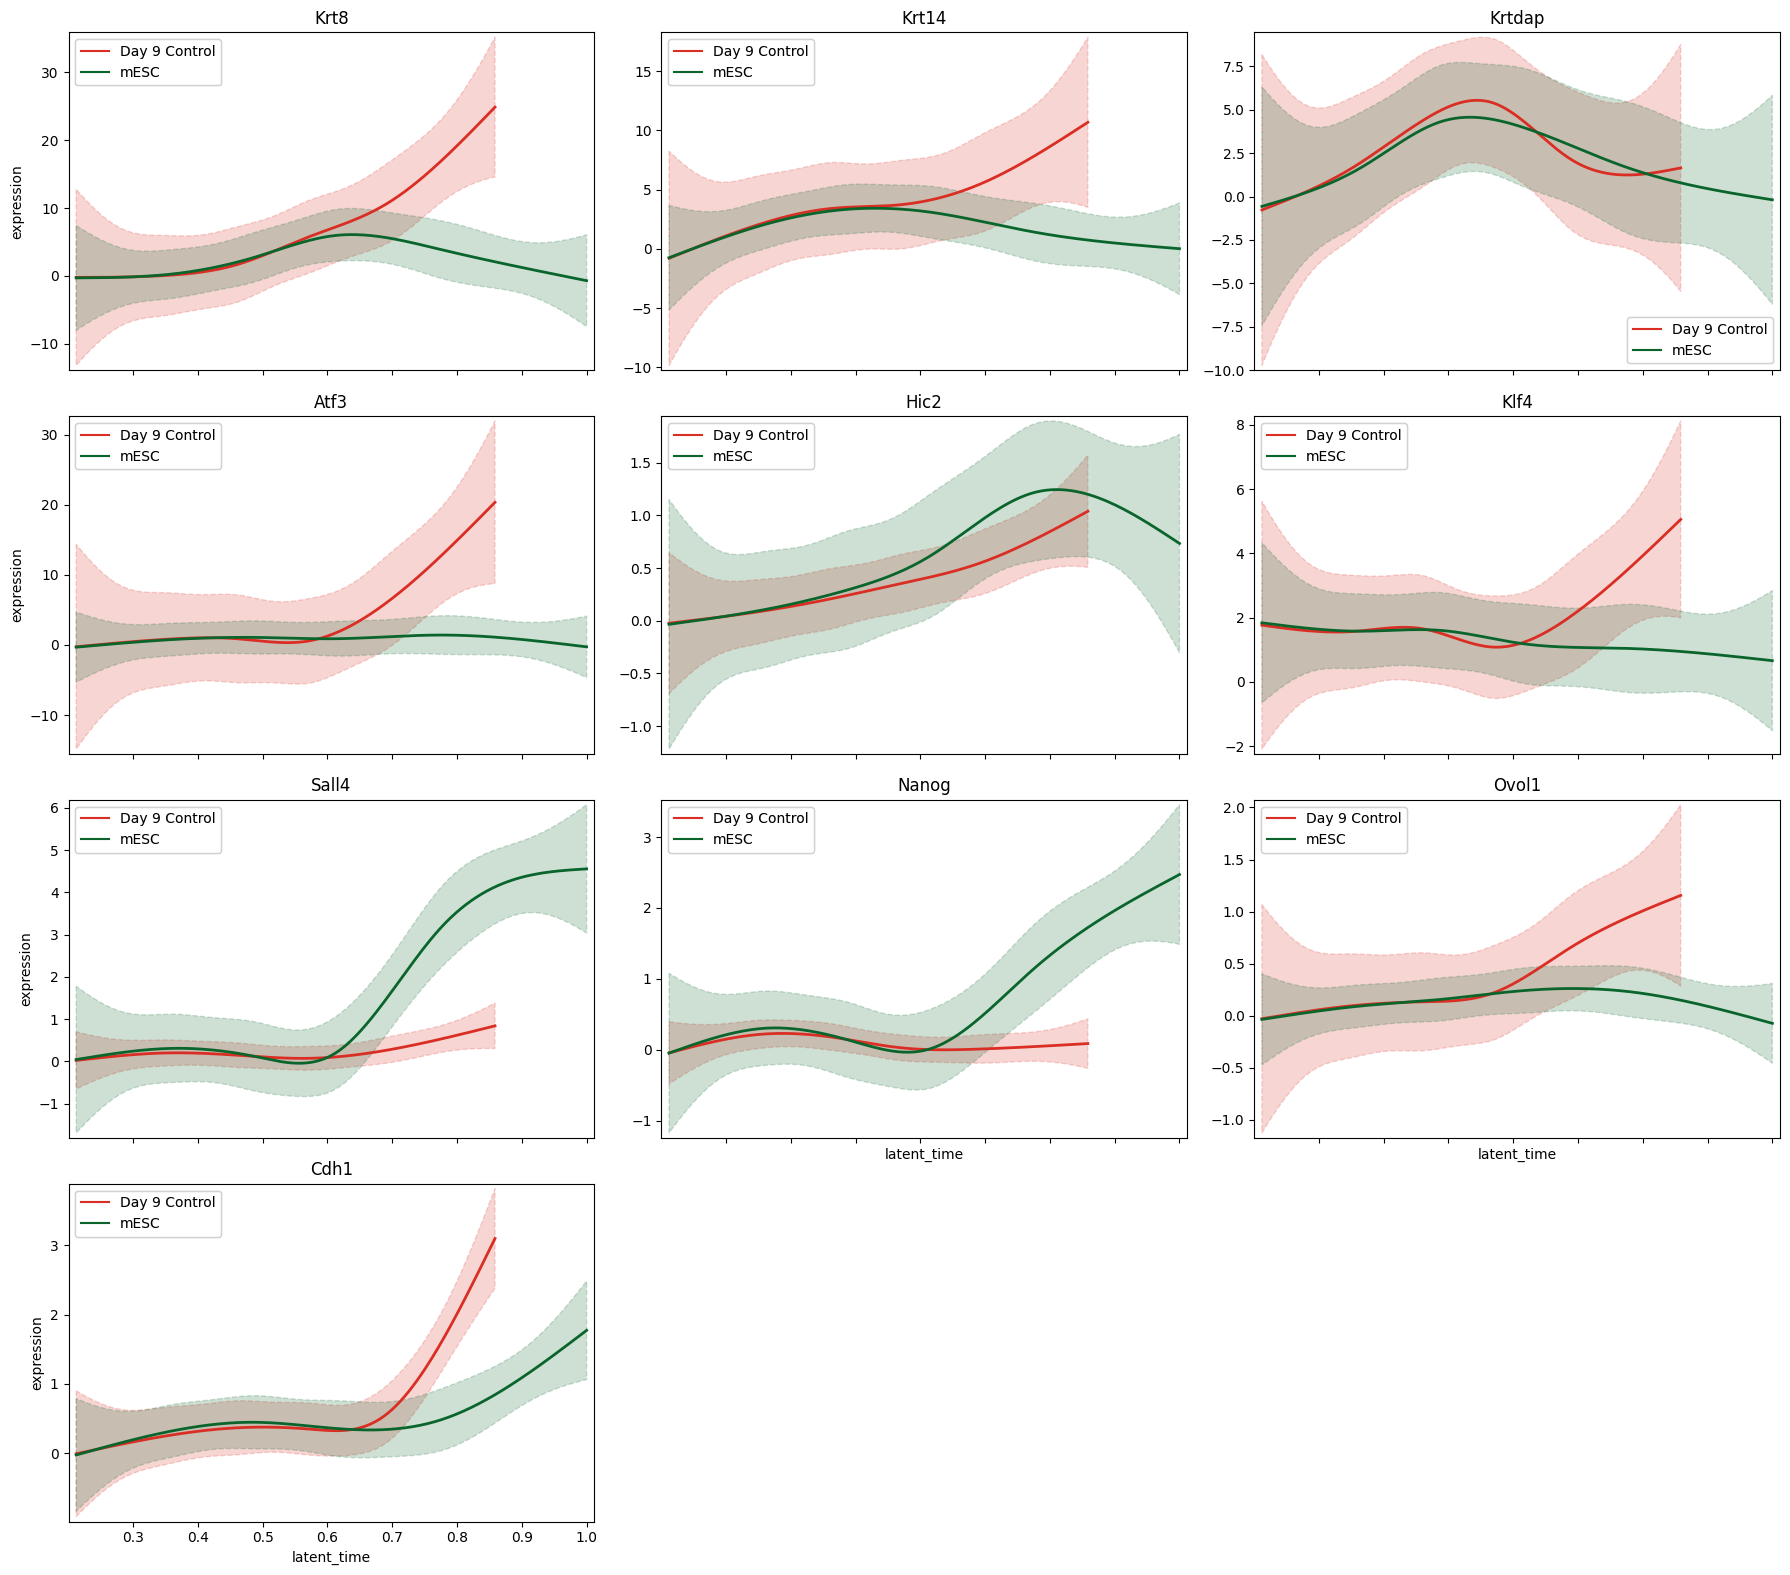

In [ ]:
# Control and Hic2 group trends

trend_genes = ["Krt8", "Krt14", "Krtdap", "Atf3", "Hic2", "Klf4", "Sall4", "Nanog", "Ovol1", "Cdh1"]
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0) # GAMR can be used instead to have the R model

cellrank.pl.gene_trends(
    adata[reprogramming_group_indices],
    model=model,
    genes=trend_genes,
    data_key="spliced",
    same_plot=True,
    ncols=3,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

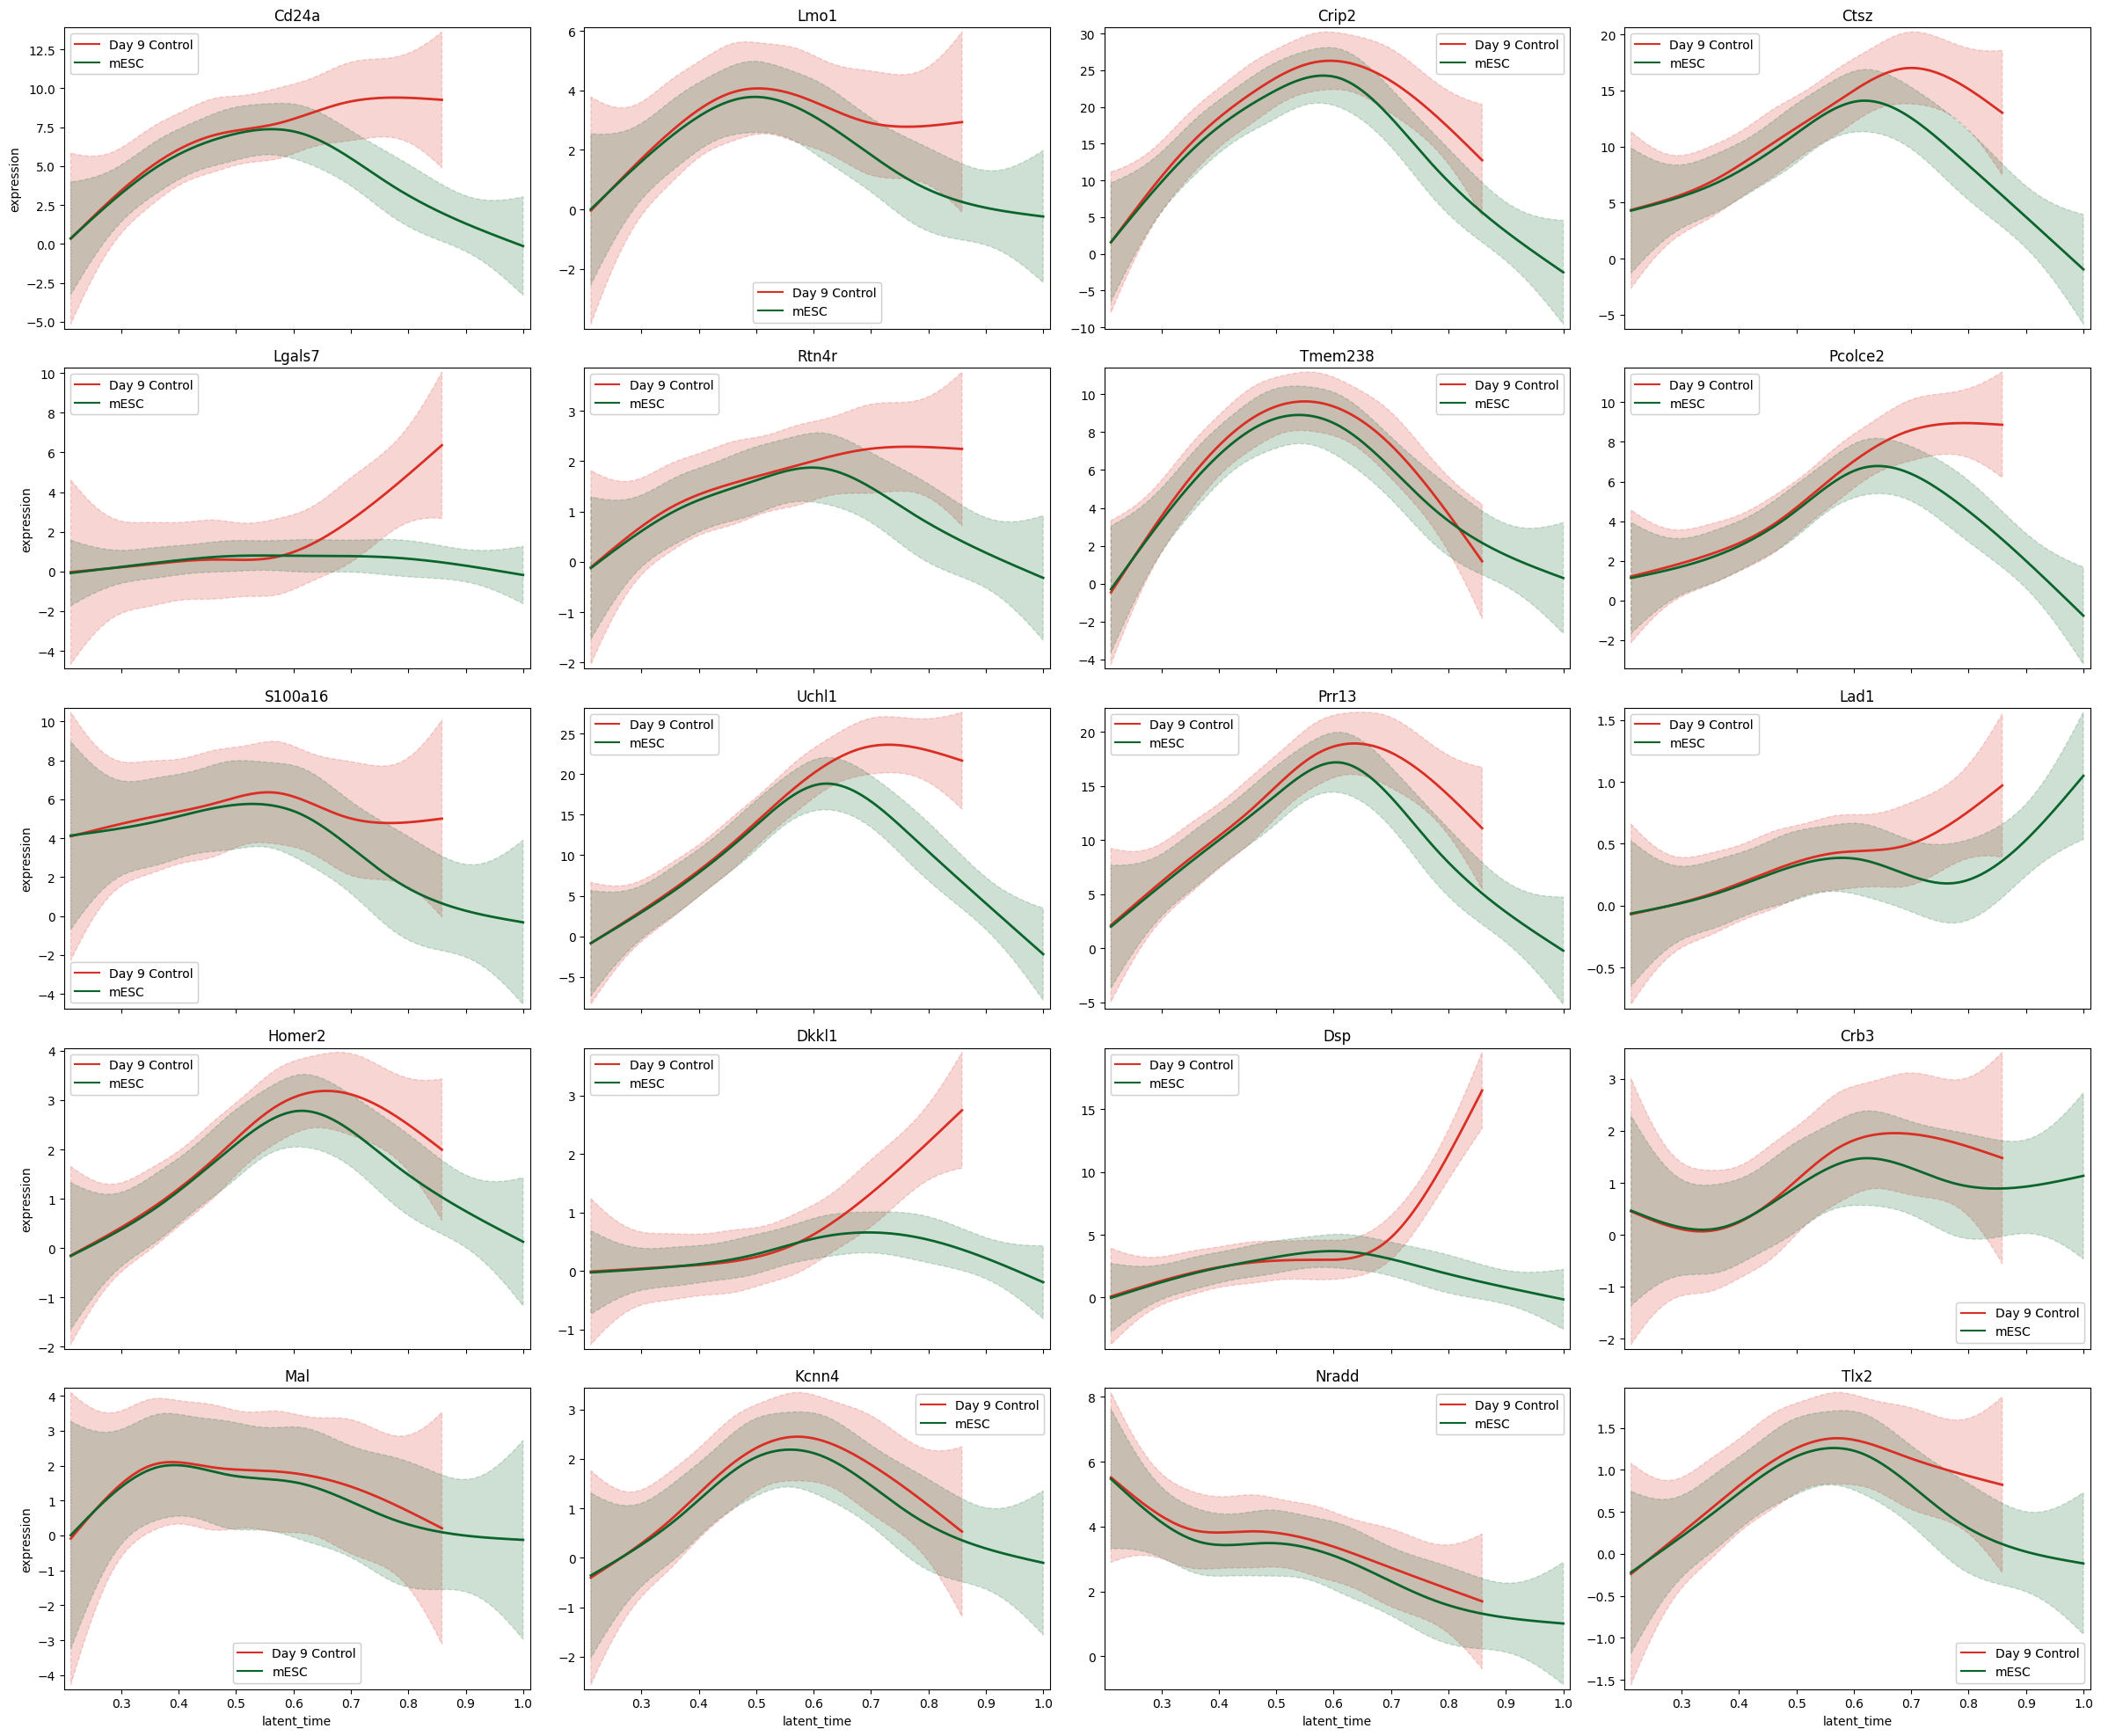

In [36]:
# The 20 strongest drivers of dead end in only control and Hic2

reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0)

dead_end = "Day 9 Control"
cellrank.pl.gene_trends(
    adata[reprogramming_group_indices],
    model=model,
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

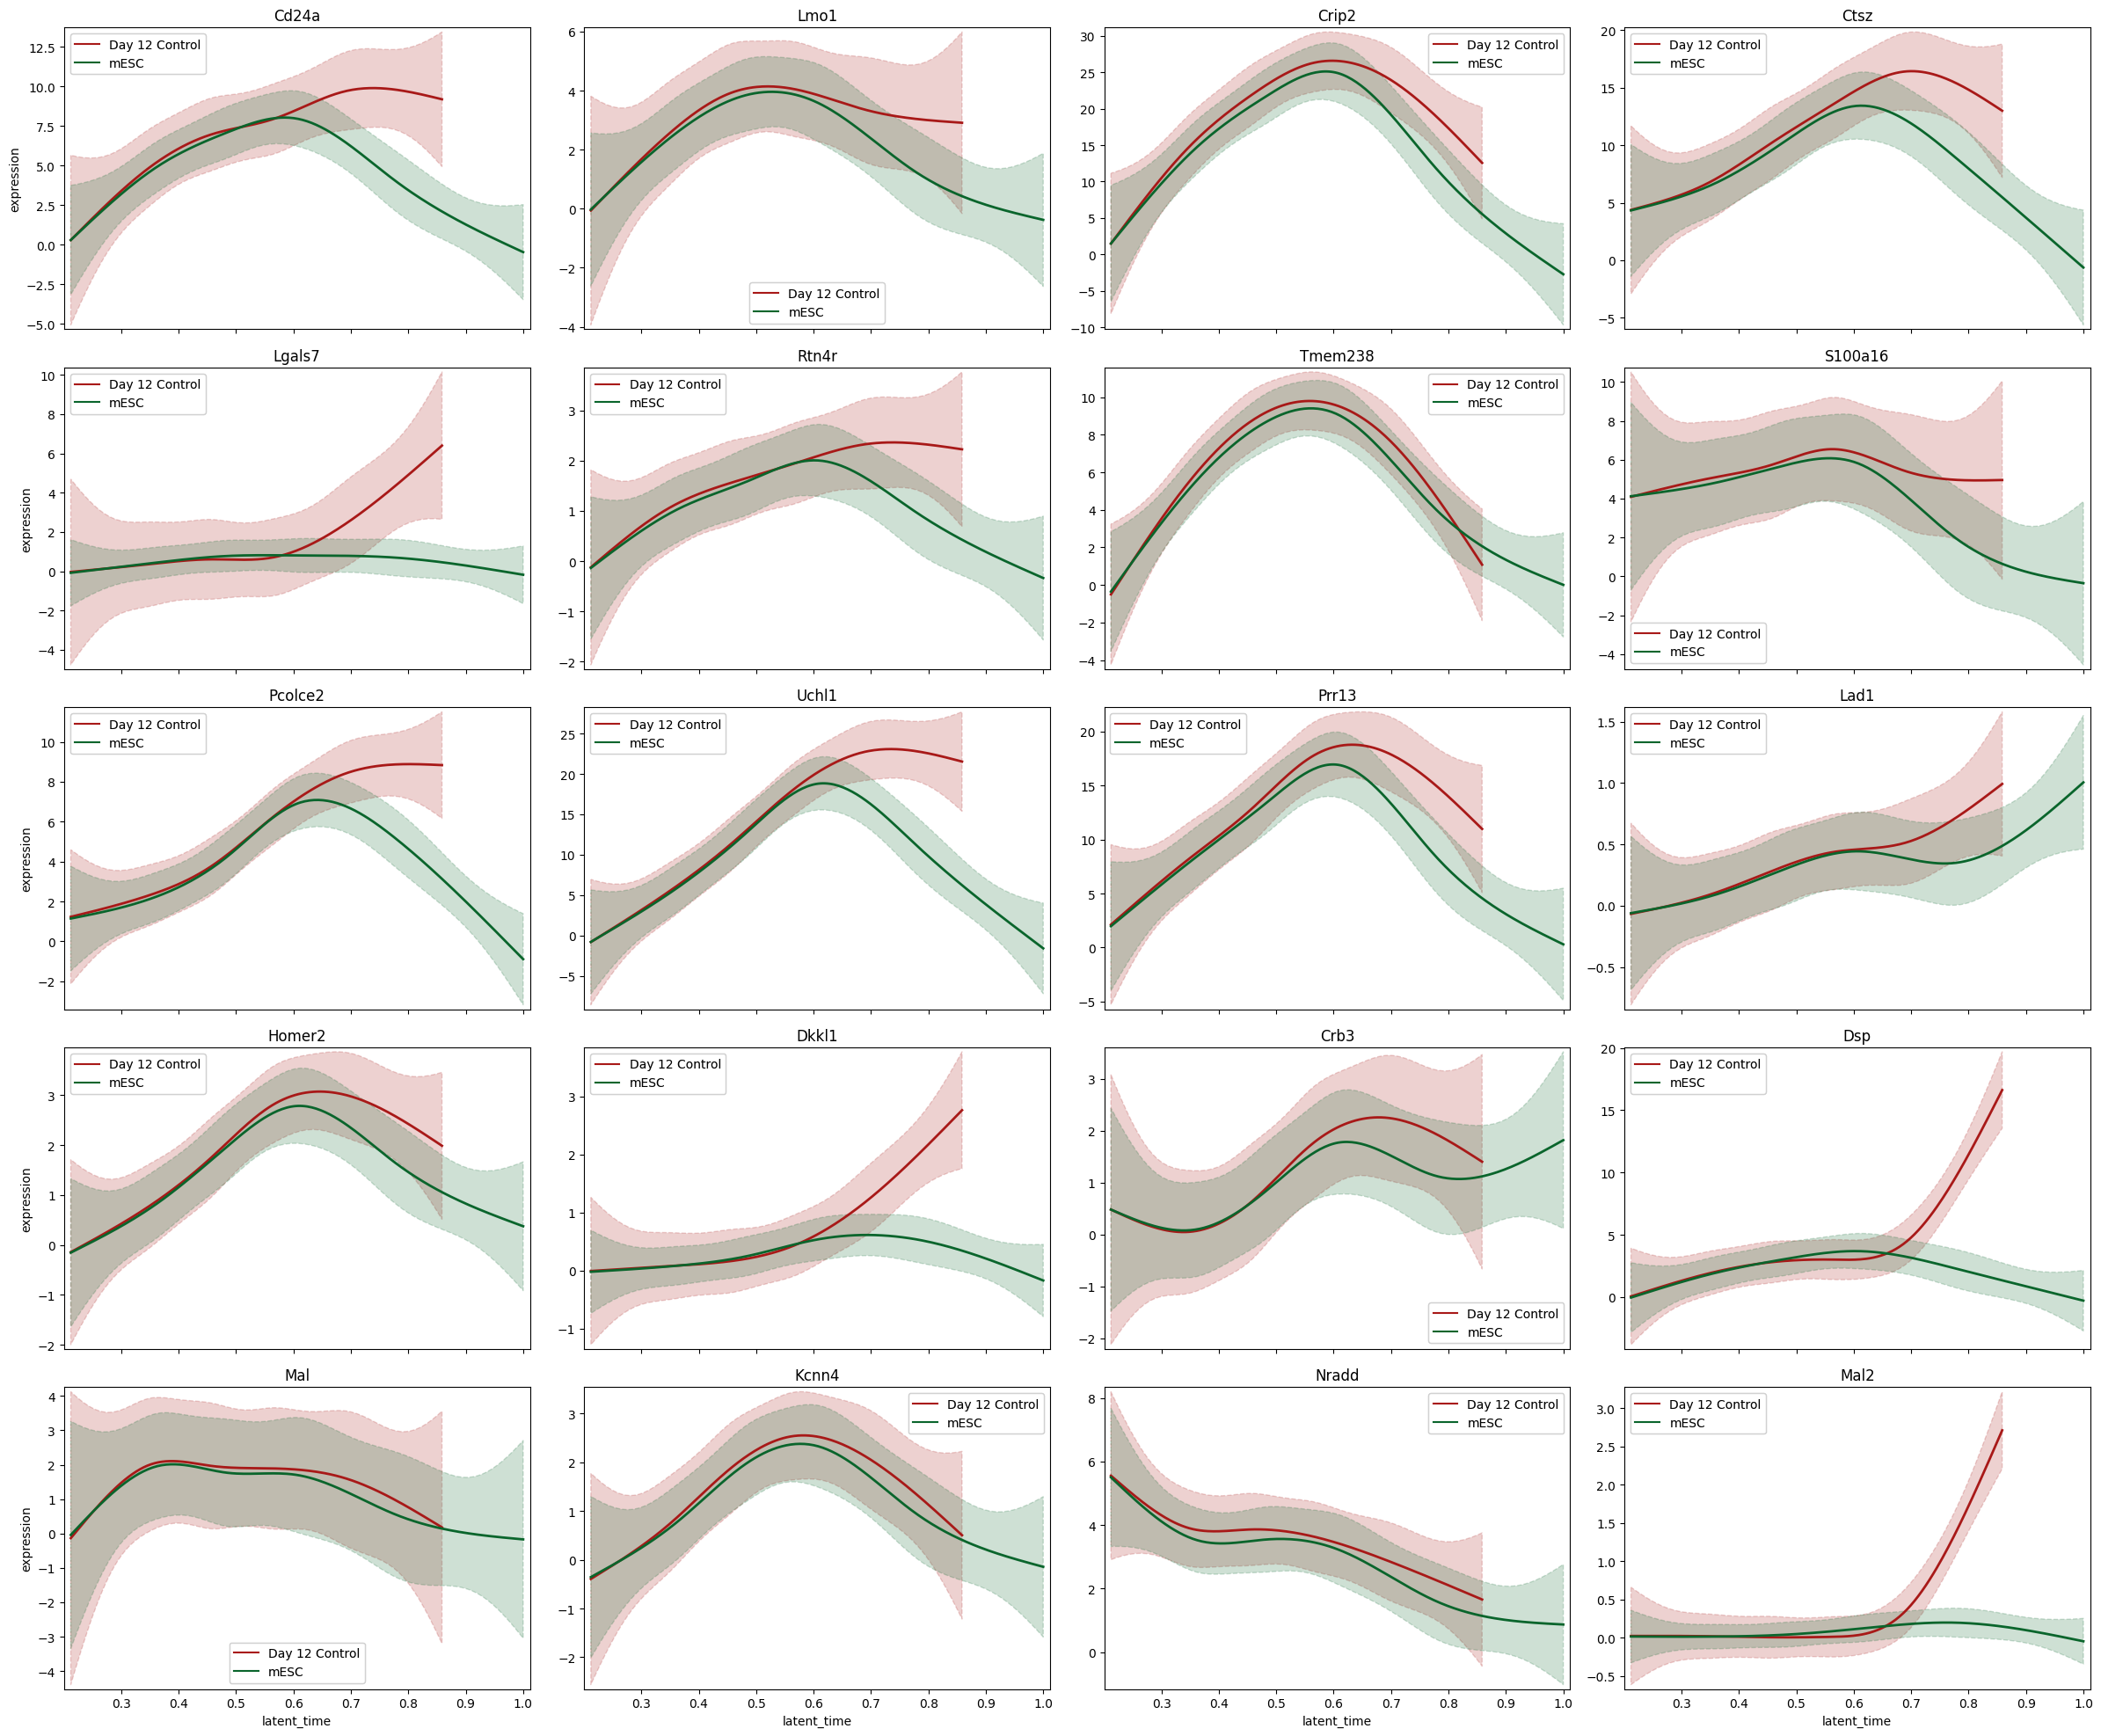

In [ ]:
# Drivers with only control

model = cellrank.models.GAMR(adata[adata.obs["group"] == "control"], n_knots=6, smoothing_penalty=10.0)
control_indices = adata.obs["group"] == "control"

dead_end = "Day 12 Control"
cellrank.pl.gene_trends(
    adata[control_indices],
    model=model,
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

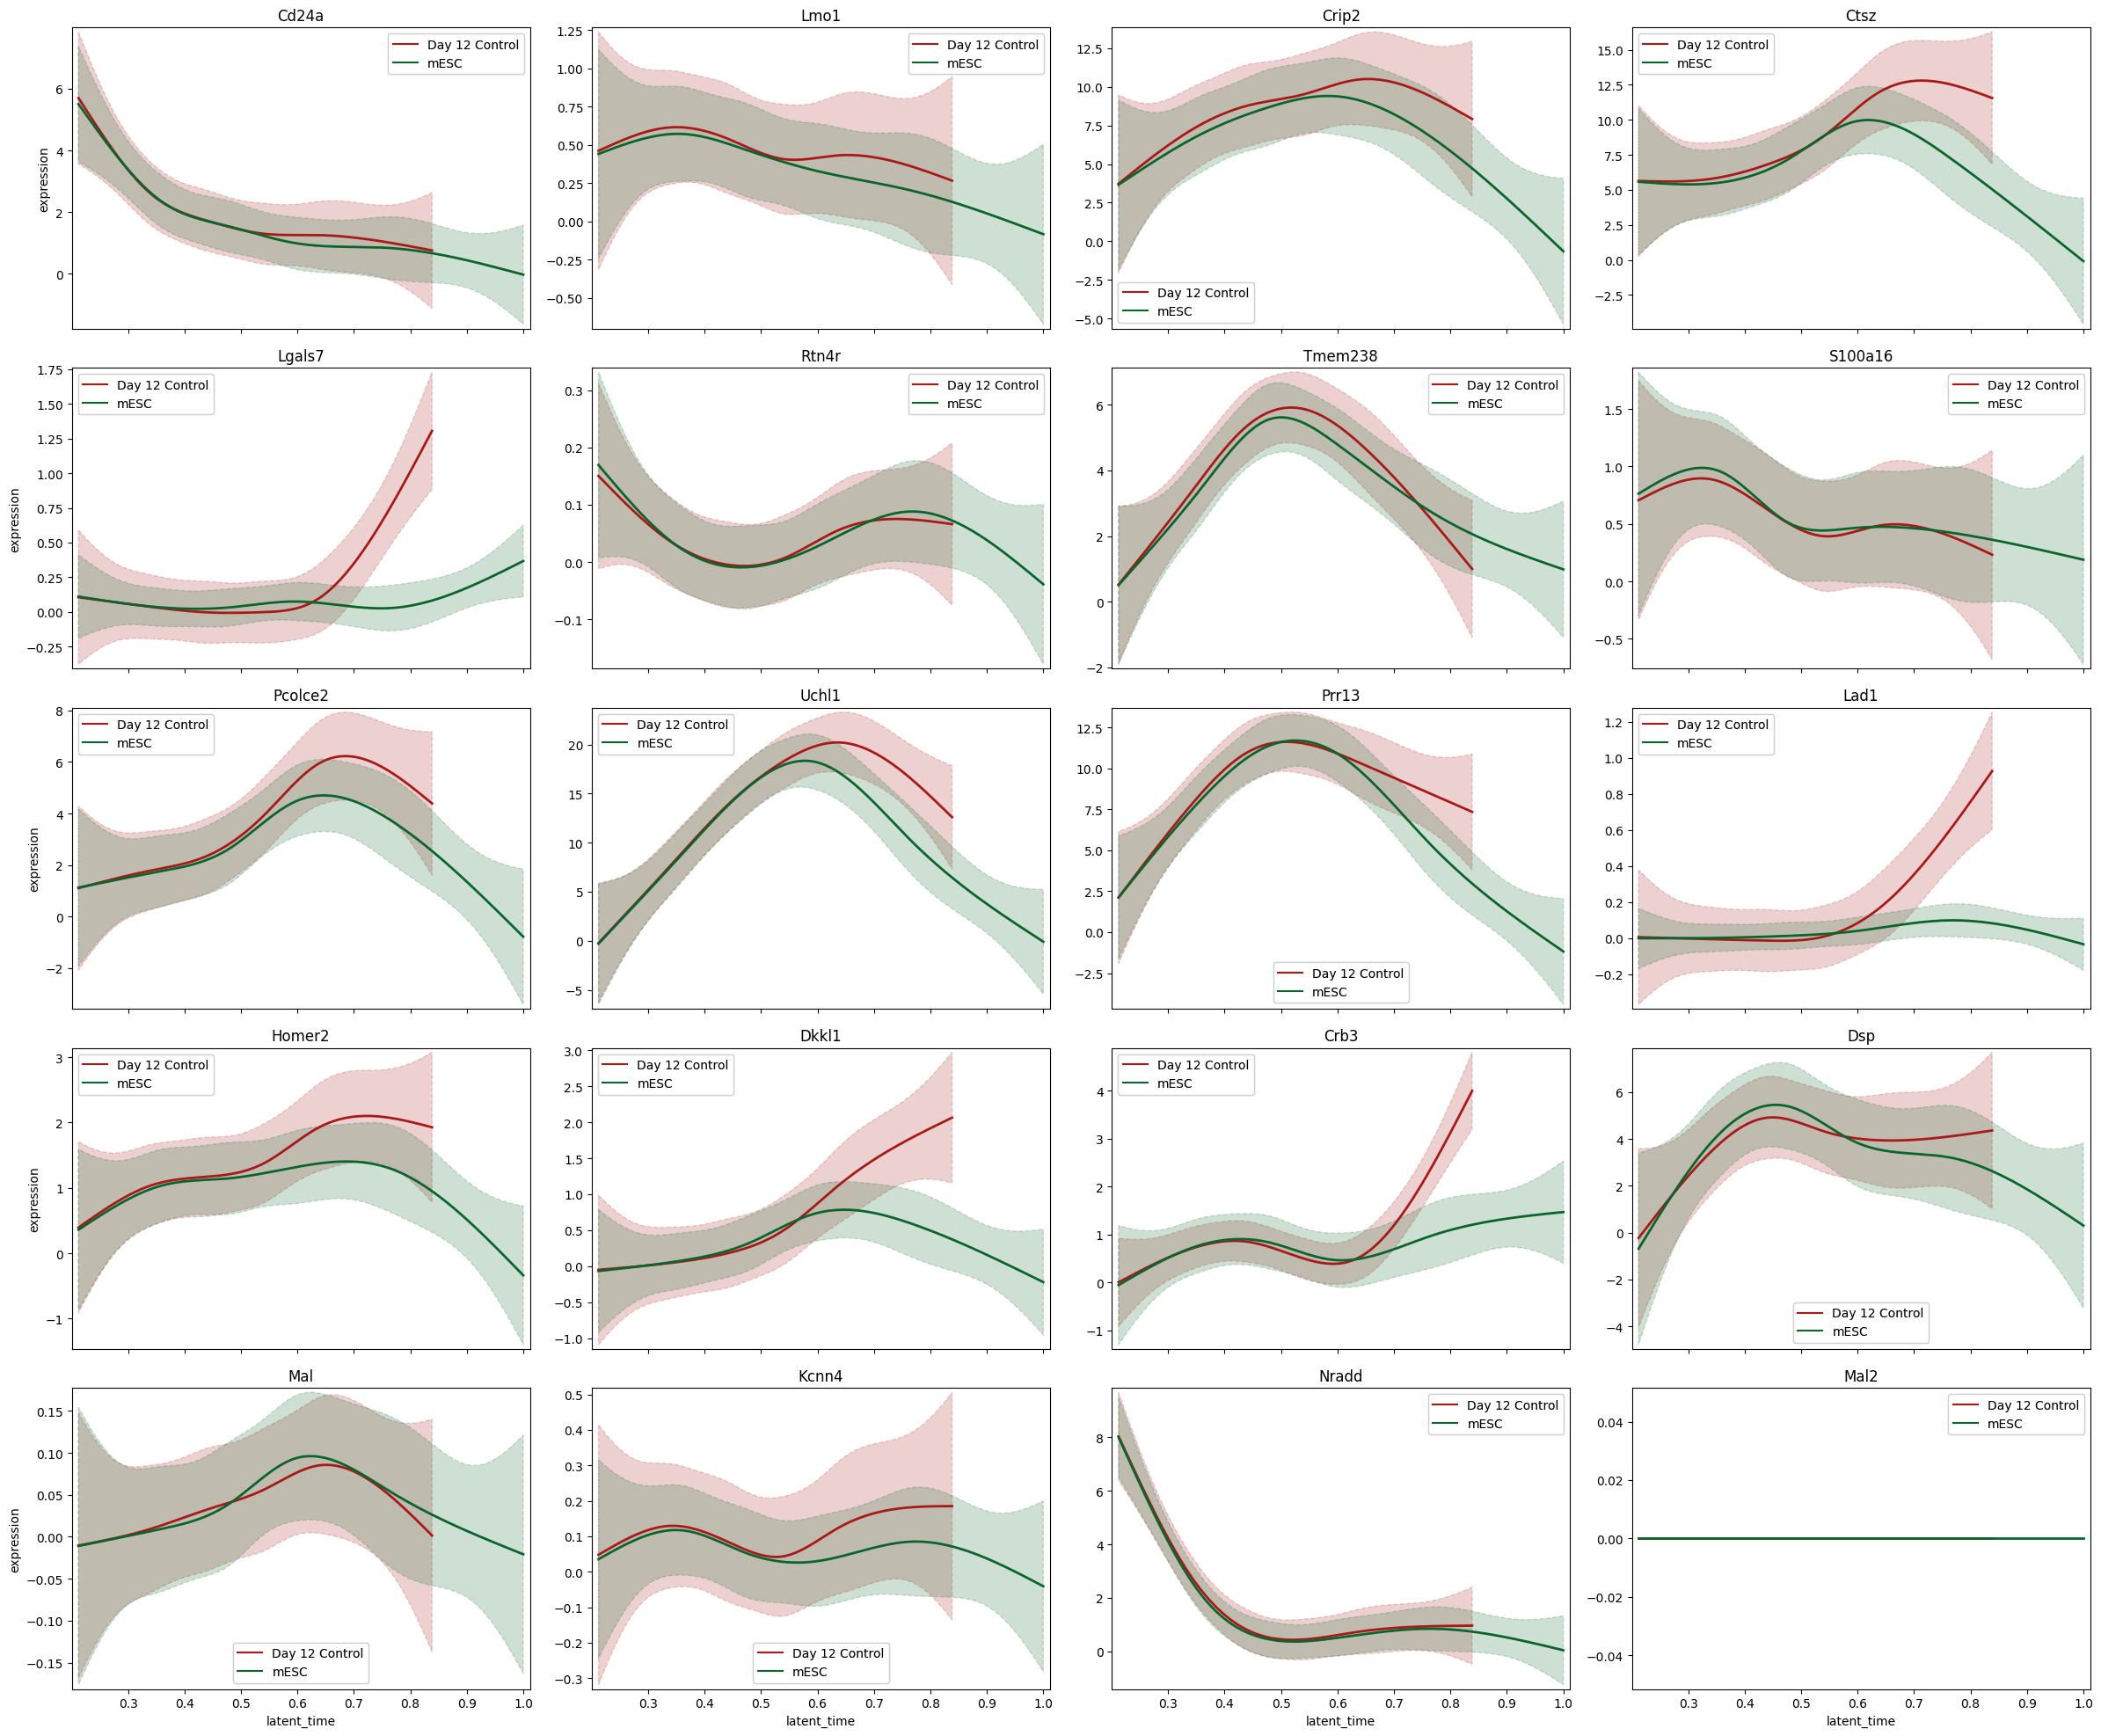

In [137]:
# Drivers with only Hic2

hic2_indices = adata.obs["group"] == "Hic2"
model = cellrank.models.GAMR(adata[hic2_indices], n_knots=6, smoothing_penalty=10.0)

dead_end = "Day 12 Control"
cellrank.pl.gene_trends(
    adata[hic2_indices],
    model=model,
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/40 [00:00<?, ?gene/s]

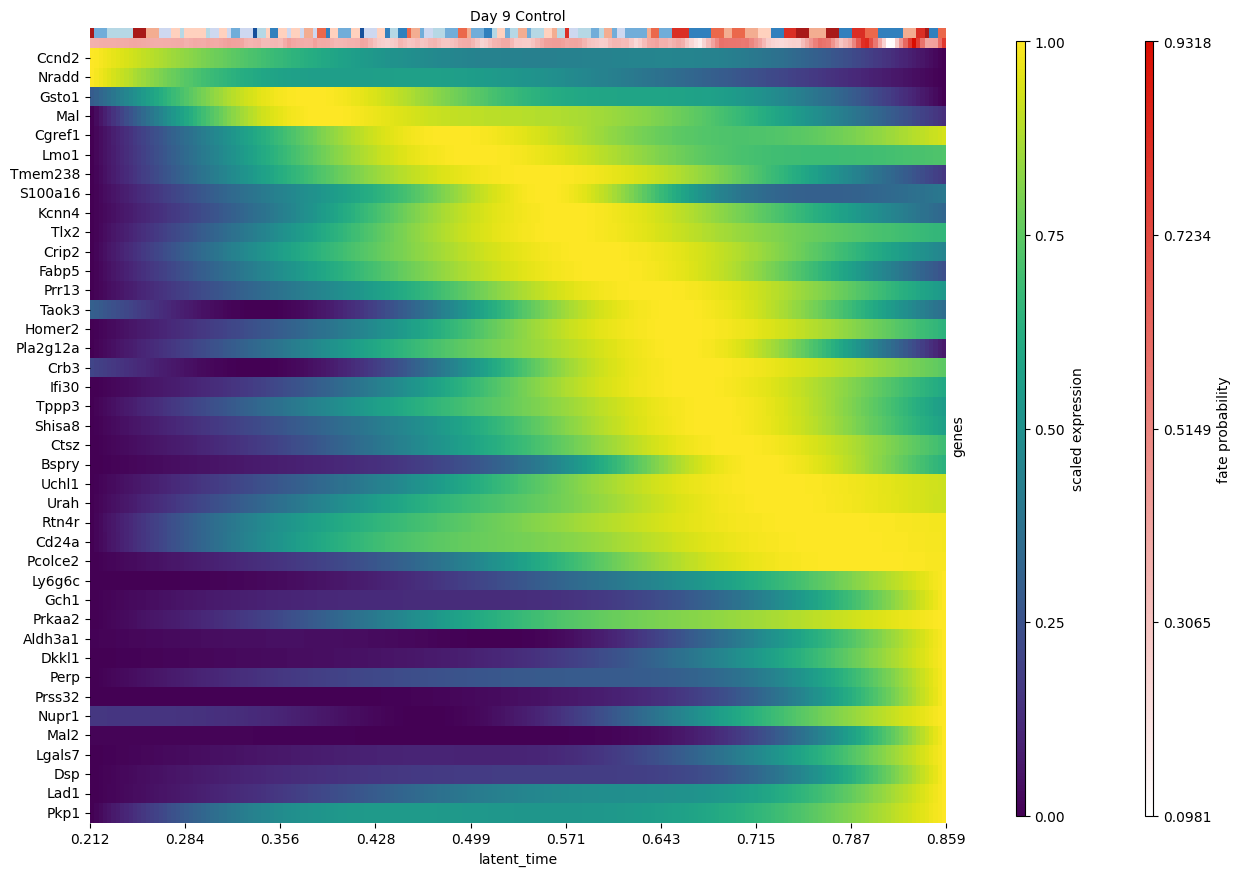

In [37]:
# Heatmap for dead-end related genes

model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0)
cellrank.pl.heatmap(
    adata[reprogramming_group_indices],
    model=model,  # use the model from before
    lineages=dead_end,
    cluster_key="sample",
    show_fate_probabilities=True,
    data_key="spliced",
    genes=driver_df.sort_values(f"{dead_end}_corr", ascending=False).head(40).index,
    time_key="latent_time",
    figsize=(12, 10),
    show_all_genes=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/40 [00:00<?, ?gene/s]

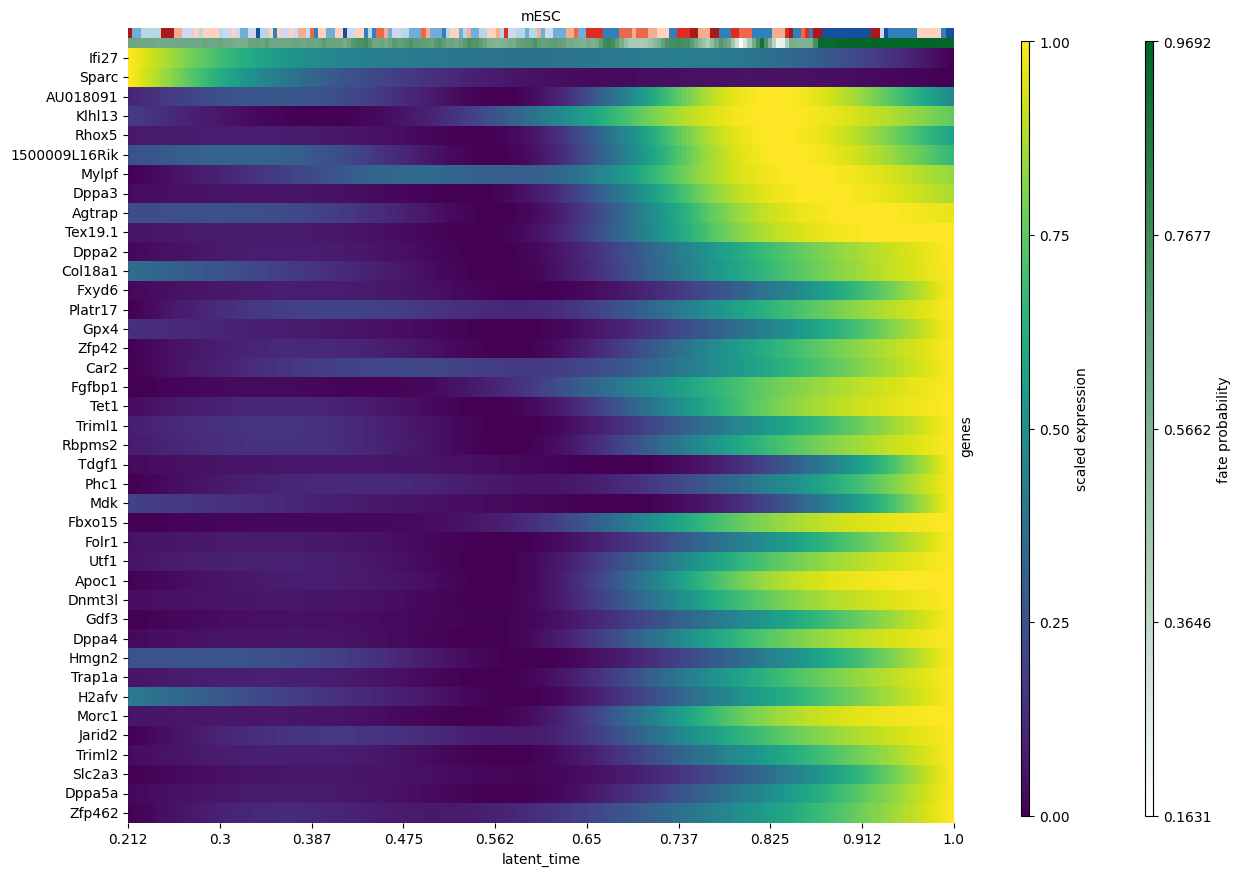

In [38]:
# Heatmap for completed reprogramming

terminal_state = "mESC"
model = cellrank.models.GAMR(adata[reprogramming_group_indices], n_knots=6, smoothing_penalty=10.0)
cellrank.pl.heatmap(
    adata[reprogramming_group_indices],
    model=model,  # use the model from before
    lineages=terminal_state,
    cluster_key="sample",
    show_fate_probabilities=True,
    data_key="spliced",
    genes=driver_df.sort_values(f"{terminal_state}_corr", ascending=False).head(40).index,
    time_key="latent_time",
    figsize=(12, 10),
    show_all_genes=True,
    weight_threshold=(1e-3, 1e-3),
)


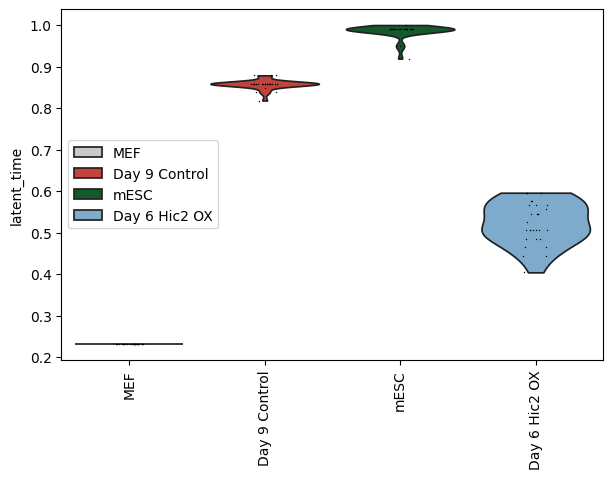

In [39]:
# Show macrostates in latent time

scanpy.pl.violin(adata, keys=["latent_time"], groupby="macrostates_fwd", rotation=90)

## GO analysis

In [43]:
# GO analysis

rank_data = driver_df[["Day 9 Control_corr"]].sort_values('Day 9 Control_corr', ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="GO_Biological_Process_2025",
    threads=16,
    min_size=5,
    max_size=1000,
    permutation_num=2000
)

print("Control drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20))

print("mESC drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20))

2026-01-28 15:58:14,650 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Control drivers:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Regulation of Trans-Synaptic Signaling (GO:009...,0.794252,1.813821,0.003641,0.873849,0.543,2/10,5.46%,Fabp5;Dlgap1
1,prerank,Epidermis Development (GO:0008544),0.651399,1.791479,0.002513,0.619051,0.6545,10/21,19.18%,Fabp5;Ovol1;Krt14;Crabp2;Spint1;Klk14;Gjb5;Emp...
2,prerank,Regulation of Glycolytic Process (GO:0006110),0.815905,1.75347,0.009804,0.690227,0.8115,5/8,12.32%,Uchl1;Nupr1;Prkaa2;Cbfa2t3;App
3,prerank,Proteolysis Involved in Protein Catabolic Proc...,0.743526,1.741332,0.010626,0.604248,0.857,3/11,5.56%,Ctsz;Ctsb;Ctsc
6,prerank,Antigen Processing and Presentation of Exogeno...,0.85799,1.680941,0.006795,0.737222,0.9785,1/6,1.30%,Ifi30
7,prerank,Antigen Processing and Presentation of Exogeno...,0.85799,1.680941,0.006795,0.737222,0.9785,1/6,1.30%,Ifi30
8,prerank,Antigen Processing and Presentation of Peptide...,0.85799,1.680941,0.006795,0.737222,0.9785,1/6,1.30%,Ifi30
12,prerank,Negative Regulation of Myeloid Leukocyte Diffe...,0.761576,1.634295,0.01623,1.0,0.9975,4/8,14.12%,Myc;Hoxa7;Runx1;Fbn1
14,prerank,Positive Regulation of Purine Nucleotide Catab...,0.869801,1.621894,0.008294,0.964508,0.999,2/5,1.80%,Uchl1;Prkaa2
15,prerank,Positive Regulation of Glycolytic Process (GO:...,0.869801,1.621894,0.008294,0.964508,0.999,2/5,1.80%,Uchl1;Prkaa2


mESC drivers:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
4,prerank,Chromatin Organization (GO:0006325),-0.64433,-1.733327,0.000799,1.0,0.523,14/25,15.27%,Hmgn2;Jarid2;Tet1;Phc1;Tcf7l1;Rest;Hmgb2;Sycp3...
5,prerank,Protein Polyubiquitination (GO:0000209),-0.729743,-1.702161,0.0075,0.85435,0.6955,7/13,15.27%,Ifi27;Arrdc4;Nedd4;Trim71;Mkrn1;Rnf31;Brca1
9,prerank,DNA Metabolic Process (GO:0006259),-0.642963,-1.64689,0.00978,1.0,0.9205,11/19,16.52%,Msh6;Hmgb2;Terf1;Top2a;Mcm3;Rec114;Tcf7l2;Horm...
10,prerank,Male Meiotic Nuclear Division (GO:0007140),-0.917591,-1.638983,0.0,1.0,0.934,4/5,8.46%,Dnmt3l;Tdrd12;Sycp3;Hsf2bp
11,prerank,Transcription by RNA Polymerase II (GO:0006366),-0.781782,-1.634578,0.006612,0.955309,0.9425,4/9,8.61%,Taf7;Anxa2;Hsf2bp;Tsc22d1
13,prerank,Transcription Initiation-Coupled Chromatin Rem...,-0.860631,-1.628429,0.002547,0.866841,0.9515,3/6,5.16%,Tet1;Ash2l;Apobec2
17,prerank,Regulation of Insulin Secretion (GO:0050796),-0.768535,-1.593437,0.006645,1.0,0.991,4/9,18.73%,Rest;Sfrp1;Tcf7l2;Trh
19,prerank,Regulation of Viral Genome Replication (GO:004...,-0.670242,-1.584174,0.018487,1.0,0.995,7/14,22.28%,Ifitm1;Ifitm3;Fam111a;Isg15;Fkbp6;Bst2;Nr5a2
24,prerank,Visual System Development (GO:0150063),-0.781841,-1.555471,0.011834,1.0,0.999,1/8,0.45%,Gdf3
27,prerank,Regulation of Cholesterol Efflux (GO:0010874),-0.822786,-1.531574,0.014097,1.0,1.0,4/6,12.12%,Apoe;Pla2g10;Ptch1;Pltp


In [45]:
# Less detailed enrichment analysis

rank_data = driver_df[["Day 9 Control_corr"]].sort_values('Day 9 Control_corr', ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="MSigDB_Hallmark_2020",
    threads=16,
    min_size=5,
    max_size=1000,
    permutation_num=2000
)

print("Control drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

print("mESC drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

2026-01-28 15:59:06,670 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Control drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
1,p53 Pathway,0.464162,1.61675,0.002882,0.2065,0.429248
2,Estrogen Response Early,0.465033,1.572828,0.004304,0.2895,0.317979
3,Cholesterol Homeostasis,0.519723,1.507241,0.039164,0.4125,0.337998
5,Androgen Response,0.500556,1.464126,0.036896,0.51,0.351267
10,Estrogen Response Late,0.403664,1.370353,0.033382,0.7295,0.508766
11,Unfolded Protein Response,0.585356,1.341044,0.151106,0.7795,0.499703
12,Allograft Rejection,0.427044,1.340763,0.067773,0.7795,0.428849
14,IL-2/STAT5 Signaling,0.370047,1.263871,0.075188,0.893,0.57171
15,mTORC1 Signaling,0.397012,1.258135,0.124524,0.8995,0.523809
16,Wnt-beta Catenin Signaling,0.601861,1.238154,0.226766,0.92,0.522547


mESC drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
0,G2-M Checkpoint,-0.550981,-1.628259,0.008668,0.1385,0.07514
4,Spermatogenesis,-0.667587,-1.467706,0.040197,0.5735,0.219932
6,DNA Repair,-0.723844,-1.438939,0.06261,0.669,0.190453
7,Oxidative Phosphorylation,-0.720102,-1.402938,0.067568,0.773,0.192852
8,Mitotic Spindle,-0.471053,-1.386316,0.053613,0.809,0.176238
9,E2F Targets,-0.495164,-1.37247,0.069919,0.838,0.162357
13,Interferon Alpha Response,-0.438646,-1.297928,0.110395,0.953,0.233262
26,Adipogenesis,-0.354239,-1.026481,0.420245,1.0,0.790711
30,Bile Acid Metabolism,-0.420198,-0.913117,0.587654,1.0,1.0
31,Interferon Gamma Response,-0.258919,-0.841391,0.796043,1.0,1.0


In [ ]:
# Cell types

rank_data = driver_df[["Day 9 Control_corr"]].sort_values('Day 9 Control_corr', ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=16,
    min_size=5,
    max_size=1000,
    permutation_num=2000
)

print("Control drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

print("mESC drivers:")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20)[["Term", "ES", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]) # Top Day 12

2026-01-28 15:59:24,464 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Control drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
0,Salivary Mucous Cells,0.741615,2.234932,0.0,0.0005,0.000663
1,Gastric Chief Cells,0.811808,2.226253,0.0,0.0005,0.000331
2,Mammary Epithelial Cells,0.636826,2.069377,0.0,0.0025,0.001105
3,Cholangiocytes,0.688019,2.0333,0.0,0.004,0.001491
4,Keratinocytes,0.62481,1.997472,0.0,0.0085,0.002519
5,Luminal Epithelial Cells,0.618775,1.990761,0.0,0.0095,0.00243
6,Foveolar Cells,0.720691,1.969173,0.0,0.014,0.00303
8,Sebocytes,0.635673,1.946247,0.0,0.0195,0.003646
9,Urothelial Cells,0.785569,1.937931,0.0,0.0195,0.003314
10,Epithelial Cells,0.541096,1.929649,0.0,0.0225,0.003381


mESC drivers:


,Term,ES,NES,NOM p-val,FWER p-val,FDR q-val
7,Pluripotent Stem Cells,-0.720983,-1.962557,0.0,0.002,0.00162
22,Epiblast Cells,-0.598218,-1.706421,0.002346,0.181,0.096789
23,Gamma Delta T Cells,-0.697348,-1.573376,0.018425,0.595,0.338965
24,Embryonic Stem Cells,-0.484401,-1.563771,0.003802,0.634,0.28318
27,Oxyphil Cells,-0.597881,-1.461745,0.051495,0.9055,0.593857
28,Adrenergic Neurons,-0.644851,-1.429577,0.061157,0.952,0.647017
30,Ependymal Cells,-0.618819,-1.410451,0.071307,0.966,0.642929
31,Myocytes,-0.475051,-1.402825,0.059342,0.972,0.59491
38,Osteocytes,-0.429089,-1.326837,0.065611,0.9975,0.903097
39,Microglia,-0.428561,-1.307725,0.081585,0.9985,0.923346


In [49]:
# Get libraries

panglao_lib = gseapy.get_library(name='PanglaoDB_Augmented_2021', organism='Mouse')
go_lib = gseapy.get_library(name='GO_Biological_Process_2025', organism='Mouse')
hallmark_lib = gseapy.get_library(name='MSigDB_Hallmark_2020', organism='Mouse')

In [50]:
# Specific gene groups
target_sets = {
    "Apoptosis Activation": go_lib["Positive Regulation of Apoptotic Process (GO:0043065)"],
    "Apoptosis Inhibition": go_lib["Negative Regulation of Apoptotic Process (GO:0043066)"],
    "Cell Cycle Inhibition": go_lib["Negative Regulation of Cell Cycle (GO:0045786)"],
    "Cell Cycle Activation": go_lib["Positive Regulation of Cell Cycle (GO:0045787)"],
    "Apoptosis Signaling Inhibition": go_lib["Negative Regulation of Apoptotic Signaling Pathway (GO:2001234)"],
    "Apoptosis Signaling Activation": go_lib["Positive Regulation of Apoptotic Signaling Pathway (GO:2001235)"],
    "Stem Cell Proliferation": go_lib["Positive Regulation of Stem Cell Proliferation (GO:2000648)"],
    "Stem Cell Inhibited Proliferation": go_lib["Negative Regulation of Stem Cell Population Maintenance (GO:1902455)"],
    "Stem Cell Inhibited Differentiation": go_lib["Negative Regulation of Stem Cell Differentiation (GO:2000737)"],
    "Stem Cell Differentiation": go_lib["Positive Regulation of Stem Cell Differentiation (GO:2000738)"],
    "DNA Damage Response": go_lib["DNA Damage Response (GO:0006974)"],
    "DNA_Repair": hallmark_lib['DNA Repair'],
    "P53_Pathway": hallmark_lib['p53 Pathway'],
    "Keratinocytes": panglao_lib["Keratinocytes"],
    "Epithelial cells": panglao_lib["Epithelial Cells"]
}

rank_data = driver_df[["Day 9 Control_corr"]].sort_values('Day 9 Control_corr', ascending=False).dropna()

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets=target_sets,
    threads=16,
    min_size=5,
    max_size=2000,
    permutation_num=1000,
    seed=0
)

pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-01-28 16:00:55,484 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Keratinocytes,0.62481,1.990018,0.0,0.0,0.0,22/41,16.98%,Lgals7;Lad1;Pkp1;Perp;Ovol1;Anxa8;S100a14;Krt1...
1,prerank,Epithelial cells,0.541096,1.943002,0.0,0.000608,0.001,32/67,19.08%,Lad1;Crb3;Mal2;Ovol1;Krt8;Dgat2;Gpx2;Misp;S100...
2,prerank,P53_Pathway,0.464162,1.598789,0.002899,0.03528,0.084,24/60,18.58%,Ccnd2;Ifi30;Nupr1;Perp;Cdkn1a;Sat1;Gpx2;Krt17;...
3,prerank,Apoptosis Signaling Activation,0.653418,1.532072,0.0475,0.0441,0.14,5/11,16.88%,Nupr1;Bbc3;App;Tnfrsf12a;Ddit3
7,prerank,Apoptosis Inhibition,0.211255,0.808817,0.931973,0.937713,0.982,18/107,15.07%,Ccnd2;Nupr1;Prkaa2;Cd44;Myc;Anxa5;Tmbim1;Ddah2...
10,prerank,Cell Cycle Inhibition,0.281087,0.701827,0.871605,0.914031,0.994,1/14,1.40%,Nupr1
12,prerank,Apoptosis Signaling Inhibition,-0.236796,-0.563571,0.97479,0.983019,1.0,4/14,33.40%,Tcf7l2;Bmp4;Thbs1;Clu
11,prerank,Stem Cell Proliferation,-0.284064,-0.577739,0.958621,1.0,1.0,1/8,7.46%,Nanog
9,prerank,Cell Cycle Activation,-0.290677,-0.711786,0.869984,1.0,1.0,2/16,4.96%,Tcf7l1;Cited2
8,prerank,Apoptosis Activation,-0.242467,-0.777942,0.889717,1.0,1.0,27/63,36.05%,Dlc1;Rest;Gadd45b;Top2a;Bnip3;Tsc22d1;Sfrp1;Ec...


# Save results

In [ ]:
# Save results

# base_name = "cellrank_1.3"

# adata.write_h5ad(
#     working_directory+f"/{base_name} cells.h5ad",
#     compression=hdf5plugin.FILTERS["zstd"]
# )

# dead_end_adata.write_h5ad(
#     working_directory+f"/{base_name} dead end genes.h5ad",
#     compression=hdf5plugin.FILTERS["zstd"]
# )

# mESC_adata.write_h5ad(
#     working_directory+f"/{base_name} mESC genes.h5ad",
#     compression=hdf5plugin.FILTERS["zstd"]
# )

# driver_df.to_csv(
#     working_directory+f"{base_name} driver genes.csv",
# )